## 🏠 House Price Prediction using Machine Learning

##  Introduction

House Price Prediction is a supervised machine learning regression problem.  
The objective of this project is to accurately predict the **SalePrice** of houses using historical housing data and advanced machine learning techniques.

This project follows a complete end-to-end data science workflow:
- Data Analysis
- Feature Engineering
- Data Preprocessing
- Model Training
- Model Evaluation
- Final Prediction.

In [4]:
import pandas as pd                                                                                                      # data analysis and manipulation
import numpy as np                                                                                                       # numerical computing
from scipy import stats                                                                                                  # statistical functions
from sklearn.metrics import mean_squared_error                                                                           # model evaluation
import matplotlib.pyplot as plt                                                                                          # data visualization
import seaborn as sns                                                                                                    # statistical data visualization
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score                                      # splitting data
from sklearn.compose import make_column_transformer, ColumnTransformer                                                   # feature engineering
from sklearn.pipeline import Pipeline, make_pipeline                                                                     # building ML pipelines
from sklearn.impute import SimpleImputer                                                                                 # handling missing values
from sklearn.preprocessing import OrdinalEncoder, StandardScaler, OneHotEncoder                                          # data preprocessing
from sklearn.linear_model import LinearRegression, Ridge                                                                 # regression models
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, VotingRegressor,StackingRegressor         # ensemble model
from xgboost import XGBRegressor                                                                                         # extreme gradient boosting models
import lightgbm as lgbm                                                                                                  # light gradient boosting models 



import warnings                                                                                                          # handling warnings
warnings.filterwarnings('ignore')                                                                                        # ignore warnings for cleaner output      


  # Load Dataset

In [5]:
housing_data = pd.read_csv(r'C:\Users\ADMIN\Downloads\Project data sets\python\.venv\projects\mini projects\data.csv')               # load dataset


## Data Fields

Below is a brief description of the key variables present in the dataset.

### Target Variable
- **SalePrice** – The property’s sale price in dollars (target variable).

### Property Classification & Zoning
- **MSSubClass** – The building class.
- **MSZoning** – General zoning classification.

### Lot & Land Details
- **LotFrontage** – Linear feet of street connected to the property.
- **LotArea** – Lot size in square feet.
- **Street** – Type of road access.
- **Alley** – Type of alley access.
- **LotShape** – General shape of the property.
- **LandContour** – Flatness of the property.
- **Utilities** – Type of utilities available.
- **LotConfig** – Lot configuration.
- **LandSlope** – Slope of the property.

### Location & Neighborhood
- **Neighborhood** – Physical locations within Ames city limits.
- **Condition1** – Proximity to main road or railroad.
- **Condition2** – Proximity to main road or railroad (if a second is present).

### Building Structure
- **BldgType** – Type of dwelling.
- **HouseStyle** – Style of dwelling.
- **OverallQual** – Overall material and finish quality.
- **OverallCond** – Overall condition rating.
- **YearBuilt** – Original construction date.
- **YearRemodAdd** – Remodel date.

### Roof & Exterior
- **RoofStyle** – Type of roof.
- **RoofMatl** – Roof material.
- **Exterior1st** – Exterior covering on house.
- **Exterior2nd** – Exterior covering on house (if more than one material).
- **MasVnrType** – Masonry veneer type.
- **MasVnrArea** – Masonry veneer area in square feet.
- **ExterQual** – Exterior material quality.
- **ExterCond** – Present condition of exterior material.

### Foundation & Basement
- **Foundation** – Type of foundation.
- **BsmtQual** – Height of the basement.
- **BsmtCond** – General condition of the basement.
- **BsmtExposure** – Walkout or garden-level basement walls.
- **BsmtFinType1** – Quality of basement finished area.
- **BsmtFinSF1** – Type 1 finished basement square feet.
- **BsmtFinType2** – Quality of second finished area.
- **BsmtFinSF2** – Type 2 finished basement square feet.
- **BsmtUnfSF** – Unfinished basement square feet.
- **TotalBsmtSF** – Total basement square footage.

### Heating & Electrical
- **Heating** – Type of heating.
- **HeatingQC** – Heating quality and condition.
- **CentralAir** – Central air conditioning.
- **Electrical** – Electrical system.

### Living Area
- **1stFlrSF** – First floor square feet.
- **2ndFlrSF** – Second floor square feet.
- **LowQualFinSF** – Low quality finished square feet.
- **GrLivArea** – Above-grade living area square feet.

### Bathrooms & Rooms
- **BsmtFullBath** – Basement full bathrooms.
- **BsmtHalfBath** – Basement half bathrooms.
- **FullBath** – Full bathrooms above grade.
- **HalfBath** – Half bathrooms above grade.
- **Bedroom** – Number of bedrooms.
- **Kitchen** – Number of kitchens.
- **KitchenQual** – Kitchen quality.
- **TotRmsAbvGrd** – Total rooms above grade.
- **Functional** – Home functionality rating.

### Fireplace & Garage
- **Fireplaces** – Number of fireplaces.
- **FireplaceQu** – Fireplace quality.
- **GarageType** – Garage location.
- **GarageYrBlt** – Year garage was built.
- **GarageFinish** – Interior finish of the garage.
- **GarageCars** – Garage capacity in number of cars.
- **GarageArea** – Garage area in square feet.
- **GarageQual** – Garage quality.
- **GarageCond** – Garage condition.

### Outdoor Features
- **PavedDrive** – Paved driveway.
- **WoodDeckSF** – Wood deck area.
- **OpenPorchSF** – Open porch area.
- **EnclosedPorch** – Enclosed porch area.
- **3SsnPorch** – Three-season porch area.
- **ScreenPorch** – Screen porch area.
- **PoolArea** – Pool area.
- **PoolQC** – Pool quality.
- **Fence** – Fence quality.

### Miscellaneous & Sale Details
- **MiscFeature** – Miscellaneous feature not covered elsewhere.
- **MiscVal** – Dollar value of miscellaneous feature.
- **MoSold** – Month sold.
- **YrSold** – Year sold.
- **SaleType** – Type of sale.
- **SaleCondition** – Condition of sale.


In [6]:
housing_data             # display the dataset                                      

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,1456,60,RL,62.0,7917,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,175000
1456,1457,20,RL,85.0,13175,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,2,2010,WD,Normal,210000
1457,1458,70,RL,66.0,9042,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,GdPrv,Shed,2500,5,2010,WD,Normal,266500
1458,1459,20,RL,68.0,9717,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,142125


##  Dataset Description
Dataset used: **Ames Housing Dataset (Kaggle)**
### Target Variable
- `SalePrice` – Final sale price of the house

### Features
- Structural attributes (OverallQual, OverallCond)
- Location-based features (Neighborhood)
- Area-related features (LotArea, GrLivArea)
- Temporal features (YearBuilt, YearRemodAdd)
- Combination of numerical and categorical variables

----

MSSubClass: Identifies the type of dwelling involved in the sale.	

        20	1-STORY 1946 & NEWER ALL STYLES
        30	1-STORY 1945 & OLDER
        40	1-STORY W/FINISHED ATTIC ALL AGES
        45	1-1/2 STORY - UNFINISHED ALL AGES
        50	1-1/2 STORY FINISHED ALL AGES
        60	2-STORY 1946 & NEWER
        70	2-STORY 1945 & OLDER
        75	2-1/2 STORY ALL AGES
        80	SPLIT OR MULTI-LEVEL
        85	SPLIT FOYER
        90	DUPLEX - ALL STYLES AND AGES
       120	1-STORY PUD (Planned Unit Development) - 1946 & NEWER
       150	1-1/2 STORY PUD - ALL AGES
       160	2-STORY PUD - 1946 & NEWER
       180	PUD - MULTILEVEL - INCL SPLIT LEV/FOYER
       190	2 FAMILY CONVERSION - ALL STYLES AND AGES

MSZoning: Identifies the general zoning classification of the sale.
		
       A	Agriculture
       C	Commercial
       FV	Floating Village Residential
       I	Industrial
       RH	Residential High Density
       RL	Residential Low Density
       RP	Residential Low Density Park 
       RM	Residential Medium Density
	
LotFrontage: Linear feet of street connected to property

LotArea: Lot size in square feet

Street: Type of road access to property

       Grvl	Gravel	
       Pave	Paved
       	
Alley: Type of alley access to property

       Grvl	Gravel
       Pave	Paved
       NA 	No alley access
		
LotShape: General shape of property

       Reg	Regular	
       IR1	Slightly irregular
       IR2	Moderately Irregular
       IR3	Irregular
       
LandContour: Flatness of the property

       Lvl	Near Flat/Level	
       Bnk	Banked - Quick and significant rise from street grade to building
       HLS	Hillside - Significant slope from side to side
       Low	Depression
		
Utilities: Type of utilities available
		
       AllPub	All public Utilities (E,G,W,& S)	
       NoSewr	Electricity, Gas, and Water (Septic Tank)
       NoSeWa	Electricity and Gas Only
       ELO	Electricity only	
	
LotConfig: Lot configuration

       Inside	Inside lot
       Corner	Corner lot
       CulDSac	Cul-de-sac
       FR2	Frontage on 2 sides of property
       FR3	Frontage on 3 sides of property
	
LandSlope: Slope of property
		
       Gtl	Gentle slope
       Mod	Moderate Slope	
       Sev	Severe Slope
	
Neighborhood: Physical locations within Ames city limits

       Blmngtn	Bloomington Heights
       Blueste	Bluestem
       BrDale	Briardale
       BrkSide	Brookside
       ClearCr	Clear Creek
       CollgCr	College Creek
       Crawfor	Crawford
       Edwards	Edwards
       Gilbert	Gilbert
       IDOTRR	Iowa DOT and Rail Road
       MeadowV	Meadow Village
       Mitchel	Mitchell
       Names	North Ames
       NoRidge	Northridge
       NPkVill	Northpark Villa
       NridgHt	Northridge Heights
       NWAmes	Northwest Ames
       OldTown	Old Town
       SWISU	South & West of Iowa State University
       Sawyer	Sawyer
       SawyerW	Sawyer West
       Somerst	Somerset
       StoneBr	Stone Brook
       Timber	Timberland
       Veenker	Veenker
			
Condition1: Proximity to various conditions
	
       Artery	Adjacent to arterial street
       Feedr	Adjacent to feeder street	
       Norm	Normal	
       RRNn	Within 200' of North-South Railroad
       RRAn	Adjacent to North-South Railroad
       PosN	Near positive off-site feature--park, greenbelt, etc.
       PosA	Adjacent to postive off-site feature
       RRNe	Within 200' of East-West Railroad
       RRAe	Adjacent to East-West Railroad
	
Condition2: Proximity to various conditions (if more than one is present)
		
       Artery	Adjacent to arterial street
       Feedr	Adjacent to feeder street	
       Norm	Normal	
       RRNn	Within 200' of North-South Railroad
       RRAn	Adjacent to North-South Railroad
       PosN	Near positive off-site feature--park, greenbelt, etc.
       PosA	Adjacent to postive off-site feature
       RRNe	Within 200' of East-West Railroad
       RRAe	Adjacent to East-West Railroad
	
BldgType: Type of dwelling
		
       1Fam	Single-family Detached	
       2FmCon	Two-family Conversion; originally built as one-family dwelling
       Duplx	Duplex
       TwnhsE	Townhouse End Unit
       TwnhsI	Townhouse Inside Unit
	
HouseStyle: Style of dwelling
	
       1Story	One story
       1.5Fin	One and one-half story: 2nd level finished
       1.5Unf	One and one-half story: 2nd level unfinished
       2Story	Two story
       2.5Fin	Two and one-half story: 2nd level finished
       2.5Unf	Two and one-half story: 2nd level unfinished
       SFoyer	Split Foyer
       SLvl	Split Level
	
OverallQual: Rates the overall material and finish of the house

       10	Very Excellent
       9	Excellent
       8	Very Good
       7	Good
       6	Above Average
       5	Average
       4	Below Average
       3	Fair
       2	Poor
       1	Very Poor
	
OverallCond: Rates the overall condition of the house

       10	Very Excellent
       9	Excellent
       8	Very Good
       7	Good
       6	Above Average	
       5	Average
       4	Below Average	
       3	Fair
       2	Poor
       1	Very Poor
		
YearBuilt: Original construction date

YearRemodAdd: Remodel date (same as construction date if no remodeling or additions)

RoofStyle: Type of roof

       Flat	Flat
       Gable	Gable
       Gambrel	Gabrel (Barn)
       Hip	Hip
       Mansard	Mansard
       Shed	Shed
		
RoofMatl: Roof material

       ClyTile	Clay or Tile
       CompShg	Standard (Composite) Shingle
       Membran	Membrane
       Metal	Metal
       Roll	Roll
       Tar&Grv	Gravel & Tar
       WdShake	Wood Shakes
       WdShngl	Wood Shingles
		
Exterior1st: Exterior covering on house

       AsbShng	Asbestos Shingles
       AsphShn	Asphalt Shingles
       BrkComm	Brick Common
       BrkFace	Brick Face
       CBlock	Cinder Block
       CemntBd	Cement Board
       HdBoard	Hard Board
       ImStucc	Imitation Stucco
       MetalSd	Metal Siding
       Other	Other
       Plywood	Plywood
       PreCast	PreCast	
       Stone	Stone
       Stucco	Stucco
       VinylSd	Vinyl Siding
       Wd Sdng	Wood Siding
       WdShing	Wood Shingles
	
Exterior2nd: Exterior covering on house (if more than one material)

       AsbShng	Asbestos Shingles
       AsphShn	Asphalt Shingles
       BrkComm	Brick Common
       BrkFace	Brick Face
       CBlock	Cinder Block
       CemntBd	Cement Board
       HdBoard	Hard Board
       ImStucc	Imitation Stucco
       MetalSd	Metal Siding
       Other	Other
       Plywood	Plywood
       PreCast	PreCast
       Stone	Stone
       Stucco	Stucco
       VinylSd	Vinyl Siding
       Wd Sdng	Wood Siding
       WdShing	Wood Shingles
	
MasVnrType: Masonry veneer type

       BrkCmn	Brick Common
       BrkFace	Brick Face
       CBlock	Cinder Block
       None	None
       Stone	Stone
	
MasVnrArea: Masonry veneer area in square feet

ExterQual: Evaluates the quality of the material on the exterior 
		
       Ex	Excellent
       Gd	Good
       TA	Average/Typical
       Fa	Fair
       Po	Poor
		
ExterCond: Evaluates the present condition of the material on the exterior
		
       Ex	Excellent
       Gd	Good
       TA	Average/Typical
       Fa	Fair
       Po	Poor
		
Foundation: Type of foundation
		
       BrkTil	Brick & Tile
       CBlock	Cinder Block
       PConc	Poured Contrete	
       Slab	Slab
       Stone	Stone
       Wood	Wood
		
BsmtQual: Evaluates the height of the basement

       Ex	Excellent (100+ inches)	
       Gd	Good (90-99 inches)
       TA	Typical (80-89 inches)
       Fa	Fair (70-79 inches)
       Po	Poor (<70 inches)
       NA	No Basement
		
BsmtCond: Evaluates the general condition of the basement

       Ex	Excellent
       Gd	Good
       TA	Typical - slight dampness allowed
       Fa	Fair - dampness or some cracking or settling
       Po	Poor - Severe cracking, settling, or wetness
       NA	No Basement
	
BsmtExposure: Refers to walkout or garden level walls

       Gd	Good Exposure
       Av	Average Exposure (split levels or foyers typically score average or above)	
       Mn	Mimimum Exposure
       No	No Exposure
       NA	No Basement
	
BsmtFinType1: Rating of basement finished area

       GLQ	Good Living Quarters
       ALQ	Average Living Quarters
       BLQ	Below Average Living Quarters	
       Rec	Average Rec Room
       LwQ	Low Quality
       Unf	Unfinshed
       NA	No Basement
		
BsmtFinSF1: Type 1 finished square feet

BsmtFinType2: Rating of basement finished area (if multiple types)

       GLQ	Good Living Quarters
       ALQ	Average Living Quarters
       BLQ	Below Average Living Quarters	
       Rec	Average Rec Room
       LwQ	Low Quality
       Unf	Unfinshed
       NA	No Basement

BsmtFinSF2: Type 2 finished square feet

BsmtUnfSF: Unfinished square feet of basement area

TotalBsmtSF: Total square feet of basement area

Heating: Type of heating
		
       Floor	Floor Furnace
       GasA	Gas forced warm air furnace
       GasW	Gas hot water or steam heat
       Grav	Gravity furnace	
       OthW	Hot water or steam heat other than gas
       Wall	Wall furnace
		
HeatingQC: Heating quality and condition

       Ex	Excellent
       Gd	Good
       TA	Average/Typical
       Fa	Fair
       Po	Poor
		
CentralAir: Central air conditioning

       N	No
       Y	Yes
		
Electrical: Electrical system

       SBrkr	Standard Circuit Breakers & Romex
       FuseA	Fuse Box over 60 AMP and all Romex wiring (Average)	
       FuseF	60 AMP Fuse Box and mostly Romex wiring (Fair)
       FuseP	60 AMP Fuse Box and mostly knob & tube wiring (poor)
       Mix	Mixed
		
1stFlrSF: First Floor square feet
 
2ndFlrSF: Second floor square feet

LowQualFinSF: Low quality finished square feet (all floors)

GrLivArea: Above grade (ground) living area square feet

BsmtFullBath: Basement full bathrooms

BsmtHalfBath: Basement half bathrooms

FullBath: Full bathrooms above grade

HalfBath: Half baths above grade

Bedroom: Bedrooms above grade (does NOT include basement bedrooms)

Kitchen: Kitchens above grade

KitchenQual: Kitchen quality

       Ex	Excellent
       Gd	Good
       TA	Typical/Average
       Fa	Fair
       Po	Poor
       	
TotRmsAbvGrd: Total rooms above grade (does not include bathrooms)

Functional: Home functionality (Assume typical unless deductions are warranted)

       Typ	Typical Functionality
       Min1	Minor Deductions 1
       Min2	Minor Deductions 2
       Mod	Moderate Deductions
       Maj1	Major Deductions 1
       Maj2	Major Deductions 2
       Sev	Severely Damaged
       Sal	Salvage only
		
Fireplaces: Number of fireplaces

FireplaceQu: Fireplace quality

       Ex	Excellent - Exceptional Masonry Fireplace
       Gd	Good - Masonry Fireplace in main level
       TA	Average - Prefabricated Fireplace in main living area or Masonry Fireplace in basement
       Fa	Fair - Prefabricated Fireplace in basement
       Po	Poor - Ben Franklin Stove
       NA	No Fireplace
		
GarageType: Garage location
		
       2Types	More than one type of garage
       Attchd	Attached to home
       Basment	Basement Garage
       BuiltIn	Built-In (Garage part of house - typically has room above garage)
       CarPort	Car Port
       Detchd	Detached from home
       NA	No Garage
		
GarageYrBlt: Year garage was built
		
GarageFinish: Interior finish of the garage

       Fin	Finished
       RFn	Rough Finished	
       Unf	Unfinished
       NA	No Garage
		
GarageCars: Size of garage in car capacity

GarageArea: Size of garage in square feet

GarageQual: Garage quality

       Ex	Excellent
       Gd	Good
       TA	Typical/Average
       Fa	Fair
       Po	Poor
       NA	No Garage
		
GarageCond: Garage condition

       Ex	Excellent
       Gd	Good
       TA	Typical/Average
       Fa	Fair
       Po	Poor
       NA	No Garage
		
PavedDrive: Paved driveway

       Y	Paved 
       P	Partial Pavement
       N	Dirt/Gravel
		
WoodDeckSF: Wood deck area in square feet

OpenPorchSF: Open porch area in square feet

EnclosedPorch: Enclosed porch area in square feet

3SsnPorch: Three season porch area in square feet

ScreenPorch: Screen porch area in square feet

PoolArea: Pool area in square feet

PoolQC: Pool quality
		
       Ex	Excellent
       Gd	Good
       TA	Average/Typical
       Fa	Fair
       NA	No Pool
		
Fence: Fence quality
		
       GdPrv	Good Privacy
       MnPrv	Minimum Privacy
       GdWo	Good Wood
       MnWw	Minimum Wood/Wire
       NA	No Fence
	
MiscFeature: Miscellaneous feature not covered in other categories
		
       Elev	Elevator
       Gar2	2nd Garage (if not described in garage section)
       Othr	Other
       Shed	Shed (over 100 SF)
       TenC	Tennis Court
       NA	None
		
MiscVal: $Value of miscellaneous feature

MoSold: Month Sold (MM)

YrSold: Year Sold (YYYY)

SaleType: Type of sale
		
       WD 	Warranty Deed - Conventional
       CWD	Warranty Deed - Cash
       VWD	Warranty Deed - VA Loan
       New	Home just constructed and sold
       COD	Court Officer Deed/Estate
       Con	Contract 15% Down payment regular terms
       ConLw	Contract Low Down payment and low interest
       ConLI	Contract Low Interest
       ConLD	Contract Low Down
       Oth	Other
		
SaleCondition: Condition of sale

       Normal	Normal Sale
       Abnorml	Abnormal Sale -  trade, foreclosure, short sale
       AdjLand	Adjoining Land Purchase
       Alloca	Allocation - two linked properties with separate deeds, typically condo with a garage unit	
       Family	Sale between family members
       Partial	Home was not completed when last assessed (associated with New Homes)

In [7]:
housing_data.head()           # display first few rows of the dataset

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [8]:
housing_data.tail()           # display last few rows of the dataset

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
1455,1456,60,RL,62.0,7917,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,175000
1456,1457,20,RL,85.0,13175,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,2,2010,WD,Normal,210000
1457,1458,70,RL,66.0,9042,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,GdPrv,Shed,2500,5,2010,WD,Normal,266500
1458,1459,20,RL,68.0,9717,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,142125
1459,1460,20,RL,75.0,9937,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,6,2008,WD,Normal,147500


In [9]:
housing_data.info()        # get dataset information

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [10]:
housing_data.columns            # display column names

Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
       'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd',
       'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
       'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1',
       'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual',
       'GarageCond', 'PavedDrive

In [11]:
housing_data.describe()           # statistical summary of numerical features

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


In [12]:
housing_data.duplicated().sum()      # check for duplicate rows

np.int64(0)

In [13]:
housing_data.isnull().sum()          # check for missing values

Id                 0
MSSubClass         0
MSZoning           0
LotFrontage      259
LotArea            0
                ... 
MoSold             0
YrSold             0
SaleType           0
SaleCondition      0
SalePrice          0
Length: 81, dtype: int64

In [14]:
housing_data.dtypes[housing_data.dtypes != 'object']    # numerical feature data types

Id                 int64
MSSubClass         int64
LotFrontage      float64
LotArea            int64
OverallQual        int64
OverallCond        int64
YearBuilt          int64
YearRemodAdd       int64
MasVnrArea       float64
BsmtFinSF1         int64
BsmtFinSF2         int64
BsmtUnfSF          int64
TotalBsmtSF        int64
1stFlrSF           int64
2ndFlrSF           int64
LowQualFinSF       int64
GrLivArea          int64
BsmtFullBath       int64
BsmtHalfBath       int64
FullBath           int64
HalfBath           int64
BedroomAbvGr       int64
KitchenAbvGr       int64
TotRmsAbvGrd       int64
Fireplaces         int64
GarageYrBlt      float64
GarageCars         int64
GarageArea         int64
WoodDeckSF         int64
OpenPorchSF        int64
EnclosedPorch      int64
3SsnPorch          int64
ScreenPorch        int64
PoolArea           int64
MiscVal            int64
MoSold             int64
YrSold             int64
SalePrice          int64
dtype: object

In [15]:
housing_data.dtypes[housing_data.dtypes == 'object']    # categorical feature data types

MSZoning         object
Street           object
Alley            object
LotShape         object
LandContour      object
Utilities        object
LotConfig        object
LandSlope        object
Neighborhood     object
Condition1       object
Condition2       object
BldgType         object
HouseStyle       object
RoofStyle        object
RoofMatl         object
Exterior1st      object
Exterior2nd      object
MasVnrType       object
ExterQual        object
ExterCond        object
Foundation       object
BsmtQual         object
BsmtCond         object
BsmtExposure     object
BsmtFinType1     object
BsmtFinType2     object
Heating          object
HeatingQC        object
CentralAir       object
Electrical       object
KitchenQual      object
Functional       object
FireplaceQu      object
GarageType       object
GarageFinish     object
GarageQual       object
GarageCond       object
PavedDrive       object
PoolQC           object
Fence            object
MiscFeature      object
SaleType        

In [16]:
housing_data.select_dtypes(include=['object']).shape[1]   # unique values in categorical features

43

In [17]:
housing_data.select_dtypes(include=['int64','float64']).shape[1]  # unique values in numerical features

38

## Exploratory Data Analysis (EDA)

EDA was performed to understand the dataset and identify important patterns

In this section, exploratory data analysis is performed to understand
data distribution, feature relationships, missing values, and outliers .


### Key EDA Steps:
- Distribution analysis of SalePrice
- Scatter plots (LotArea vs SalePrice, LotFrontage vs SalePrice)
- Outlier detection using:
  - Visualization
  - Z-score method
- Missing value analysis

EDA helped in understanding feature importance and data quality issues.

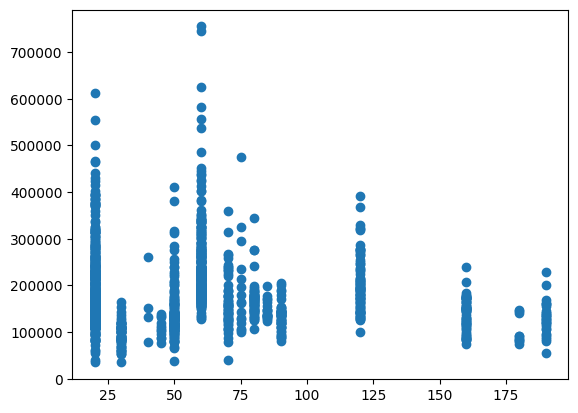

In [18]:
plt.scatter(x = 'MSSubClass',y = 'SalePrice', data = housing_data)   # visualize MSSubClass vs SalePrice

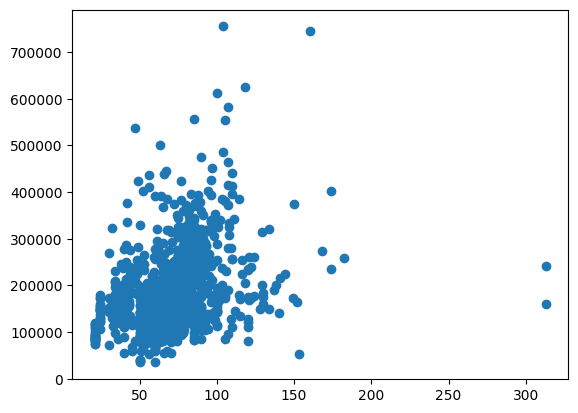

In [19]:
plt.scatter(x = 'LotFrontage',y = 'SalePrice', data = housing_data)    # visualize LotFrontage vs SalePrice

In [20]:
housing_data.query("LotFrontage  > 300")     # identify outliers in LotFrontage
# drop 935,1299

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
934,935,20,RL,313.0,27650,Pave,NaN,IR2,HLS,AllPub,...,0,NaN,NaN,NaN,0,11,2008,WD,Normal,242000
1298,1299,60,RL,313.0,63887,Pave,NaN,IR3,Bnk,AllPub,...,480,Gd,NaN,NaN,0,1,2008,New,Partial,160000


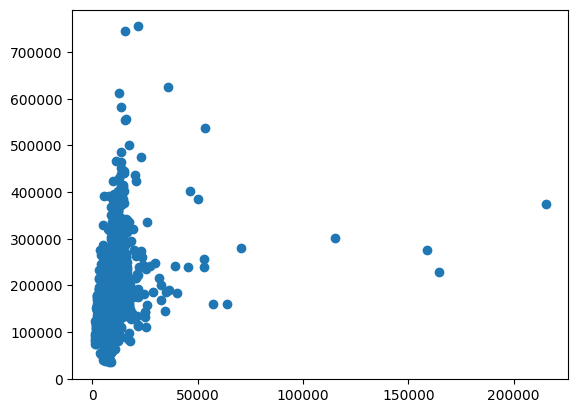

In [21]:
plt.scatter(x = 'LotArea',y = 'SalePrice', data = housing_data)     # visualize LotArea vs SalePrice

In [22]:
housing_data.query('LotArea > 55000')        # identify outliers in LotArea
# 250,314,336,452,707
# maybe 1397

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
249,250,50,RL,NaN,159000,Pave,NaN,IR2,Low,AllPub,...,0,NaN,NaN,Shed,500,6,2007,WD,Normal,277000
313,314,20,RL,150.0,215245,Pave,NaN,IR3,Low,AllPub,...,0,NaN,NaN,NaN,0,6,2009,WD,Normal,375000
335,336,190,RL,NaN,164660,Grvl,NaN,IR1,HLS,AllPub,...,0,NaN,NaN,Shed,700,8,2008,WD,Normal,228950
451,452,20,RL,62.0,70761,Pave,NaN,IR1,Low,AllPub,...,0,NaN,NaN,NaN,0,12,2006,WD,Normal,280000
706,707,20,RL,NaN,115149,Pave,NaN,IR2,Low,AllPub,...,0,NaN,NaN,NaN,0,6,2007,WD,Normal,302000
1298,1299,60,RL,313.0,63887,Pave,NaN,IR3,Bnk,AllPub,...,480,Gd,NaN,NaN,0,1,2008,New,Partial,160000
1396,1397,20,RL,NaN,57200,Pave,NaN,IR1,Bnk,AllPub,...,0,NaN,NaN,NaN,0,6,2010,WD,Normal,160000


In [23]:
pd.Series(stats.zscore(housing_data['LotArea'])).sort_values().tail(10)      # identify outliers using Z-score

384      4.268474
457      4.280500
769      4.308262
1396     4.678682
1298     5.348867
451      6.037793
706     10.486449
249     14.881285
335     15.448542
313     20.518273
dtype: float64

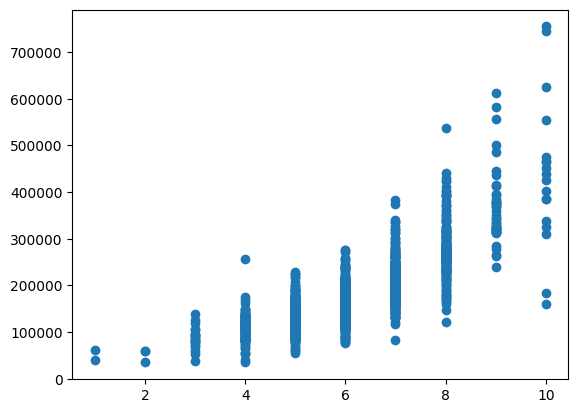

In [24]:
plt.scatter(x = 'OverallQual',y = 'SalePrice', data = housing_data)        # visualize OverallQual vs SalePrice

In [25]:
housing_data.query('OverallQual == 10')        # identify outliers in OverallQual
# 524

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
58,59,60,RL,66.0,13682,Pave,NaN,IR2,HLS,AllPub,...,0,NaN,NaN,NaN,0,10,2006,New,Partial,438780
185,186,75,RM,90.0,22950,Pave,NaN,IR2,Lvl,AllPub,...,0,NaN,GdPrv,NaN,0,6,2006,WD,Normal,475000
224,225,20,RL,103.0,13472,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,6,2009,WD,Normal,386250
389,390,60,RL,96.0,12474,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,8,2008,New,Partial,426000
440,441,20,RL,105.0,15431,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2009,WD,Normal,555000
515,516,20,RL,94.0,12220,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2009,New,Partial,402861
523,524,60,RL,130.0,40094,Pave,NaN,IR1,Bnk,AllPub,...,0,NaN,NaN,NaN,0,10,2007,New,Partial,184750
583,584,75,RM,75.0,13500,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,7,2008,WD,Normal,325000
591,592,60,RL,97.0,13478,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,6,2009,ConLI,Normal,451950
691,692,60,RL,104.0,21535,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,1,2007,WD,Normal,755000


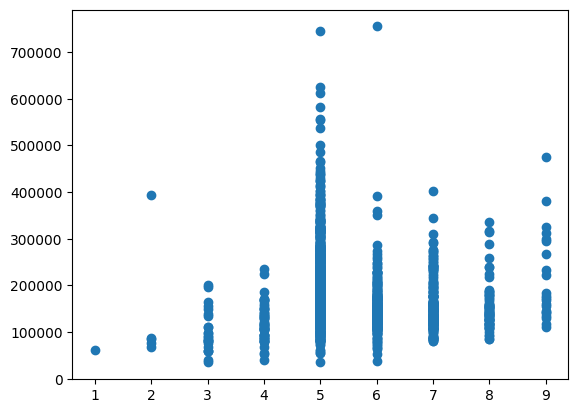

In [26]:
plt.scatter(x = 'OverallCond',y = 'SalePrice', data = housing_data)     # visualize OverallCond vs SalePrice

In [27]:
housing_data.query('OverallCond == 2')    # identify outliers in OverallCond
#379

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
88,89,50,C (all),105.0,8470,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,10,2009,ConLD,Abnorml,85000
250,251,30,RL,55.0,5350,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,GdWo,Shed,450,5,2010,WD,Normal,76500
378,379,20,RL,88.0,11394,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,6,2010,New,Partial,394432
398,399,30,RM,60.0,8967,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,11,2007,WD,Abnorml,67000
676,677,70,RM,60.0,9600,Pave,Grvl,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2006,WD,Normal,87000


In [28]:
housing_data.query('OverallCond == 5 & SalePrice > 700000')    # identify outliers in OverallCond
# 1183

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
1182,1183,60,RL,160.0,15623,Pave,NaN,IR1,Lvl,AllPub,...,555,Ex,MnPrv,NaN,0,7,2007,WD,Abnorml,745000


In [29]:
housing_data.query('OverallCond == 6 & SalePrice > 700000')    # identify outliers in OverallCond
# 692

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
691,692,60,RL,104.0,21535,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,1,2007,WD,Normal,755000


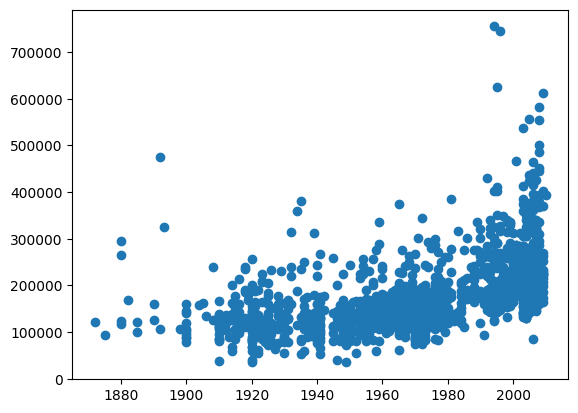

In [30]:
plt.scatter(x = 'YearBuilt',y = 'SalePrice', data = housing_data) # visualize YearBuilt vs SalePrice

In [31]:
housing_data.query('YearBuilt < 1900 & SalePrice > 400000')   # identify outliers in YearBuilt
# 186

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
185,186,75,RM,90.0,22950,Pave,NaN,IR2,Lvl,AllPub,...,0,NaN,GdPrv,NaN,0,6,2006,WD,Normal,475000


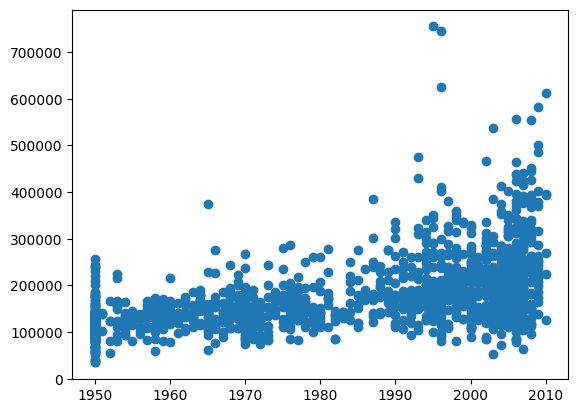

In [32]:
plt.scatter(x = 'YearRemodAdd',y = 'SalePrice', data = housing_data) # visualize YearRemodAdd vs SalePrice

In [33]:
housing_data.query('YearRemodAdd < 1970 & SalePrice > 300000')   # identify outliers in YearRemodAdd
#314    

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
313,314,20,RL,150.0,215245,Pave,NaN,IR3,Low,AllPub,...,0,NaN,NaN,NaN,0,6,2009,WD,Normal,375000


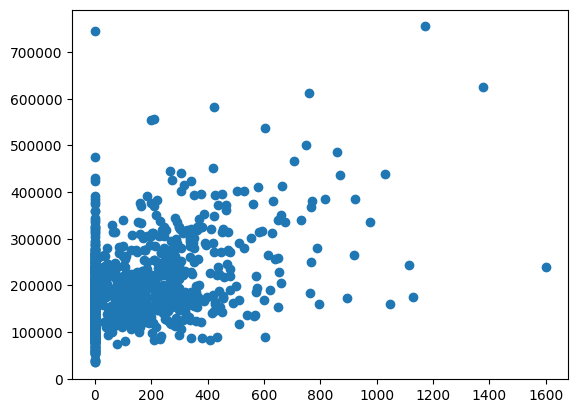

In [34]:
plt.scatter(x = 'MasVnrArea',y = 'SalePrice', data = housing_data) # visualize MasVnrArea vs SalePrice  

In [35]:
housing_data.query('MasVnrArea >1500')   # identify outliers in MasVnrArea
#298

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
297,298,60,FV,66.0,7399,Pave,Pave,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,6,2007,WD,Normal,239000


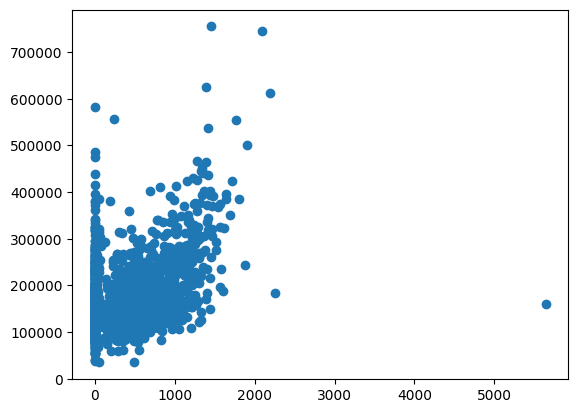

In [36]:
plt.scatter(x = 'BsmtFinSF1',y = 'SalePrice', data = housing_data) # visualize BsmtFinSF1 vs SalePrice

In [37]:
housing_data.query('BsmtFinSF1 > 3000')   # identify outliers in BsmtFinSF1
#1299

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
1298,1299,60,RL,313.0,63887,Pave,NaN,IR3,Bnk,AllPub,...,480,Gd,NaN,NaN,0,1,2008,New,Partial,160000


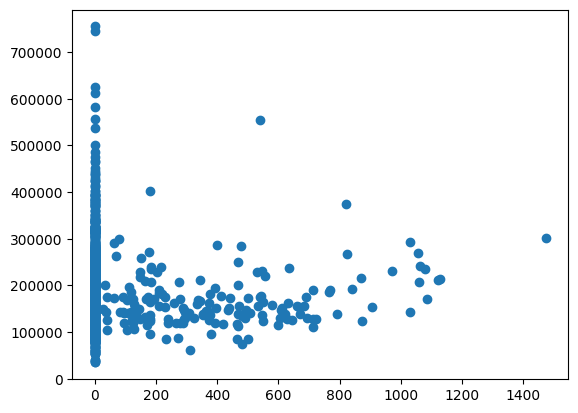

In [38]:
plt.scatter(x = 'BsmtFinSF2',y = 'SalePrice', data = housing_data)  # visualize BsmtFinSF2 vs SalePrice

In [39]:
housing_data.query('BsmtFinSF2 > 400 & SalePrice > 500000')   # identify outliers in BsmtFinSF2
#441

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
440,441,20,RL,105.0,15431,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2009,WD,Normal,555000


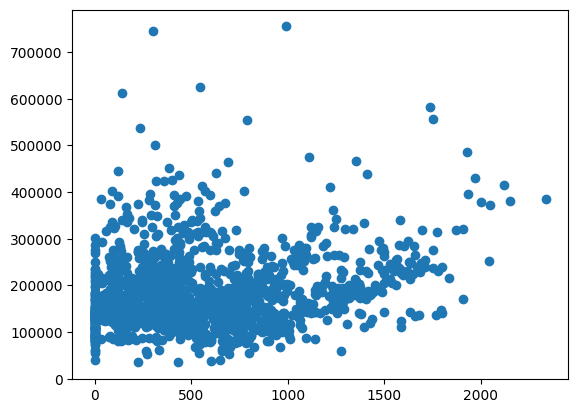

In [40]:
plt.scatter(x = 'BsmtUnfSF',y = 'SalePrice', data = housing_data)   # visualize BsmtUnfSF vs SalePrice

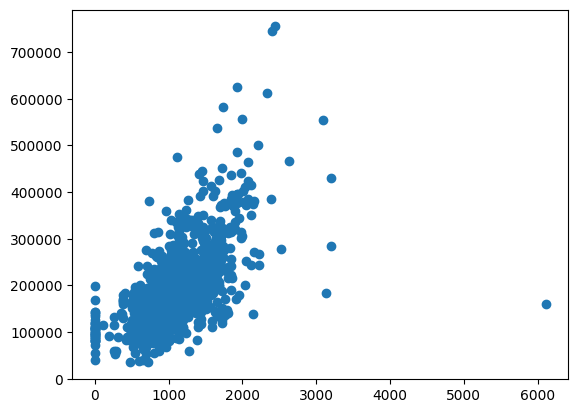

In [41]:
plt.scatter(x = 'TotalBsmtSF',y = 'SalePrice', data = housing_data)  # visualize TotalBsmtSF vs SalePrice

In [42]:
housing_data.query('TotalBsmtSF >  5000')    # identify outliers in TotalBsmtSF  
#1299 

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
1298,1299,60,RL,313.0,63887,Pave,NaN,IR3,Bnk,AllPub,...,480,Gd,NaN,NaN,0,1,2008,New,Partial,160000


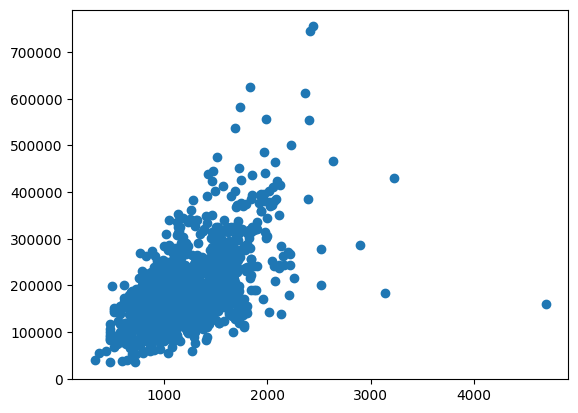

In [43]:
plt.scatter(x = '1stFlrSF',y = 'SalePrice', data = housing_data)        # visualize 1stFlrSF vs SalePrice

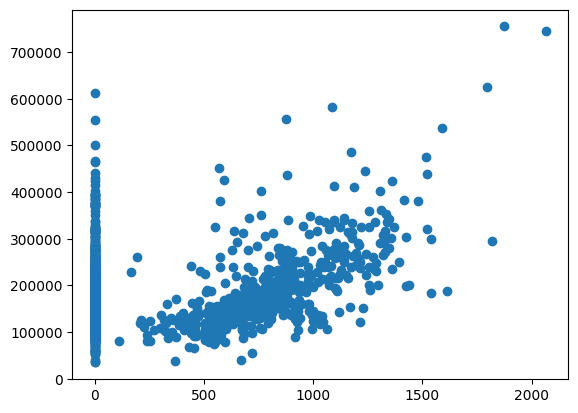

In [44]:
plt.scatter(x = '2ndFlrSF',y = 'SalePrice', data = housing_data)    # visualize 2ndFlrSF vs SalePrice

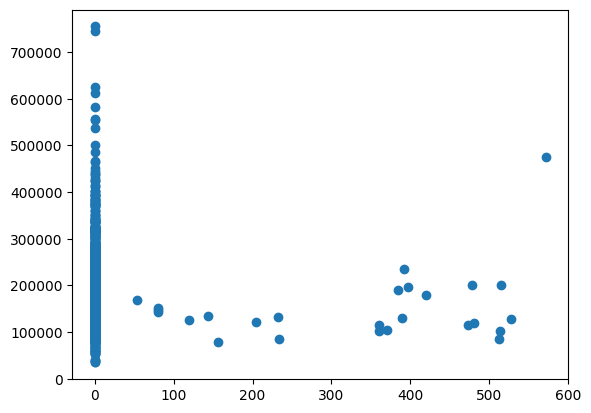

In [45]:
plt.scatter(x = 'LowQualFinSF',y = 'SalePrice', data = housing_data)    # visualize LowQualFinSF vs SalePrice

In [46]:
housing_data.query('LowQualFinSF > 500')   # identify outliers in LowQualFinSF
#186


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
88,89,50,C (all),105.0,8470,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,10,2009,ConLD,Abnorml,85000
170,171,50,RM,NaN,12358,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,128500
185,186,75,RM,90.0,22950,Pave,NaN,IR2,Lvl,AllPub,...,0,NaN,GdPrv,NaN,0,6,2006,WD,Normal,475000
635,636,190,RH,60.0,10896,Pave,Pave,Reg,Bnk,AllPub,...,0,NaN,NaN,NaN,0,3,2007,WD,Abnorml,200000
1009,1010,50,RL,60.0,6000,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,6,2006,WD,Normal,102000


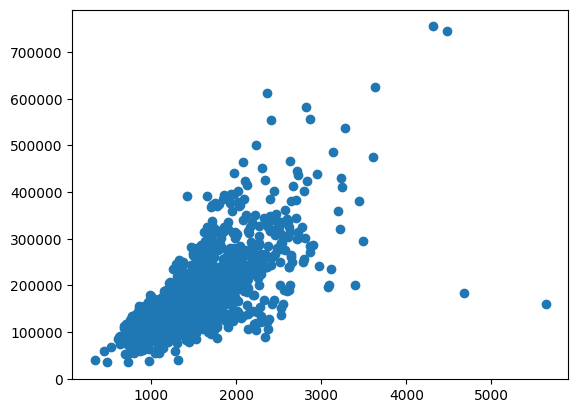

In [47]:
plt.scatter(x = 'GrLivArea',y = 'SalePrice', data = housing_data)   # visualize GrLivArea vs SalePrice

In [48]:
housing_data.query('GrLivArea > 4400')   # identify outliers in GrLivArea
#524,1299

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
523,524,60,RL,130.0,40094,Pave,NaN,IR1,Bnk,AllPub,...,0,NaN,NaN,NaN,0,10,2007,New,Partial,184750
1182,1183,60,RL,160.0,15623,Pave,NaN,IR1,Lvl,AllPub,...,555,Ex,MnPrv,NaN,0,7,2007,WD,Abnorml,745000
1298,1299,60,RL,313.0,63887,Pave,NaN,IR3,Bnk,AllPub,...,480,Gd,NaN,NaN,0,1,2008,New,Partial,160000


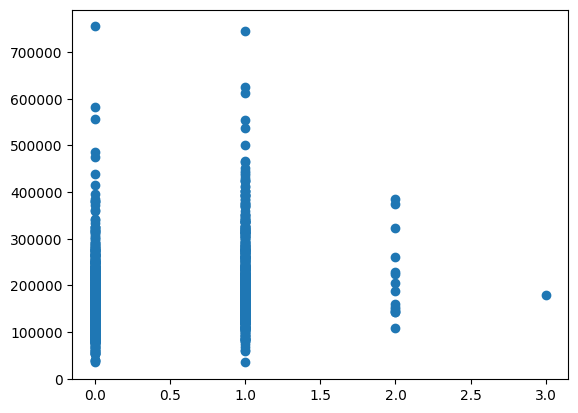

In [49]:
plt.scatter(x = 'BsmtFullBath',y = 'SalePrice', data = housing_data)    # visualize BsmtFullBath vs SalePrice

In [50]:
housing_data.query('BsmtFullBath == 3')   # identify outliers in BsmtFullBath
#739

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
738,739,90,RL,60.0,10800,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,3,2009,WD,Alloca,179000


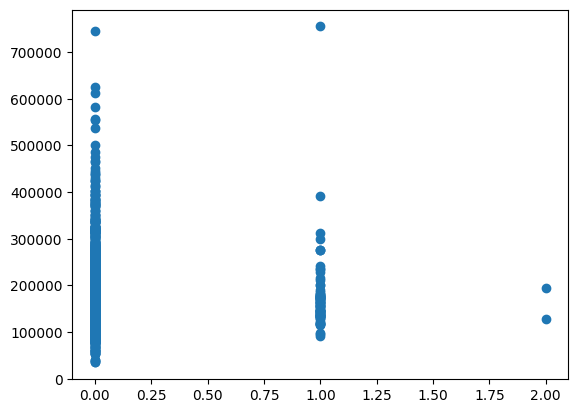

In [51]:
plt.scatter(x = 'BsmtHalfBath',y = 'SalePrice', data = housing_data) # visualize BsmtHalfBath vs SalePrice

In [52]:
pd.Series(stats.zscore(housing_data['BsmtHalfBath'])).unique()  # check unique z-scores in BsmtHalfBath

array([-0.24106104,  3.94880935,  8.13867973])

In [53]:
housing_data.query('BsmtHalfBath == 2')   # identify outliers in BsmtHalfBath
#598,955

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
597,598,120,RL,53.0,3922,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2007,New,Partial,194201
954,955,90,RL,35.0,9400,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,10,2006,WD,AdjLand,127500


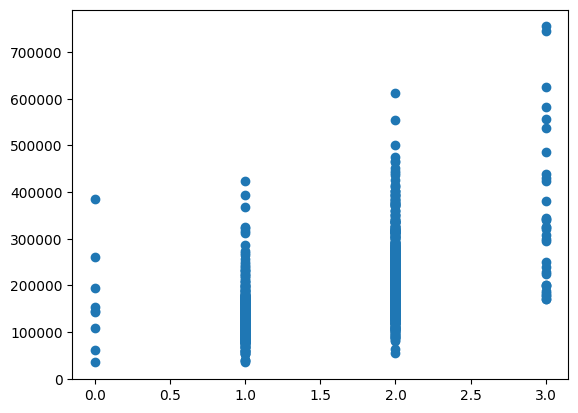

In [54]:
plt.scatter(x = 'FullBath',y = 'SalePrice', data = housing_data)   # visualize FullBath vs SalePrice                 

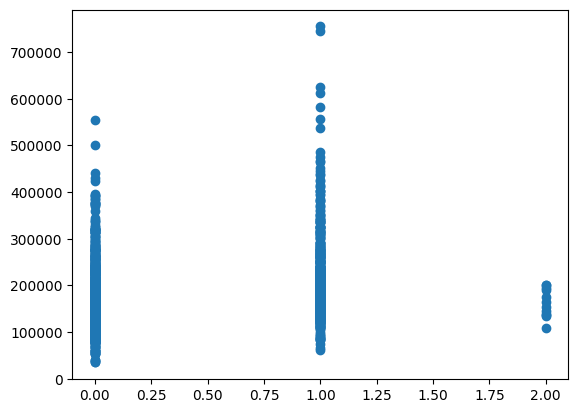

In [55]:
plt.scatter(x = 'HalfBath',y = 'SalePrice', data = housing_data) # visualize HalfBath vs SalePrice     

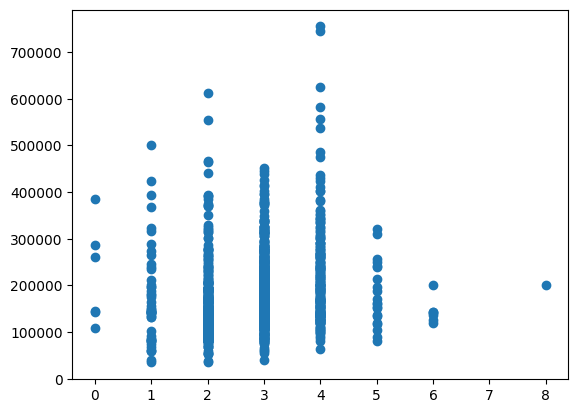

In [56]:
plt.scatter(x = 'BedroomAbvGr',y = 'SalePrice', data = housing_data)  # visualize BedroomAbvGr vs SalePrice           

In [57]:
housing_data.query('BedroomAbvGr == 8')   # identify outliers in BedroomAbvGr
#636

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
635,636,190,RH,60.0,10896,Pave,Pave,Reg,Bnk,AllPub,...,0,NaN,NaN,NaN,0,3,2007,WD,Abnorml,200000


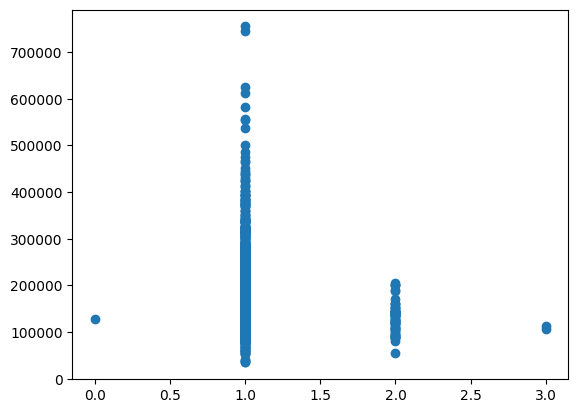

In [58]:
plt.scatter(x = 'KitchenAbvGr',y = 'SalePrice', data = housing_data)  # visualize KitchenAbvGr vs SalePrice

In [59]:
housing_data.query('KitchenAbvGr == 3')   # identify outliers in KitchenAbvGr 
#49,810

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
48,49,190,RM,33.0,4456,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,6,2009,New,Partial,113000
809,810,75,RM,90.0,8100,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,11,2009,WD,Normal,106000


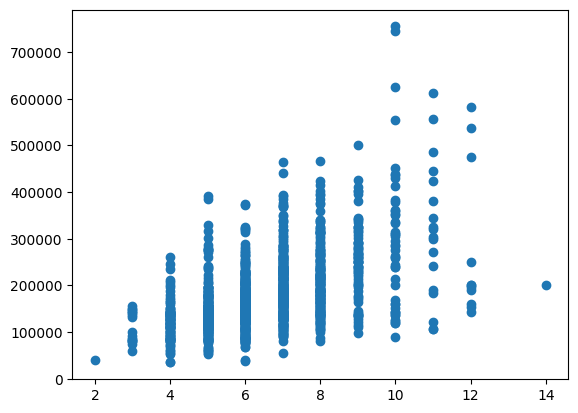

In [60]:
plt.scatter(x = 'TotRmsAbvGrd',y = 'SalePrice', data = housing_data)    # visualize TotRmsAbvGrd vs SalePrice

In [61]:
housing_data.query('TotRmsAbvGrd == 14')    # identify outliers in TotRmsAbvGrd
#636

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
635,636,190,RH,60.0,10896,Pave,Pave,Reg,Bnk,AllPub,...,0,NaN,NaN,NaN,0,3,2007,WD,Abnorml,200000


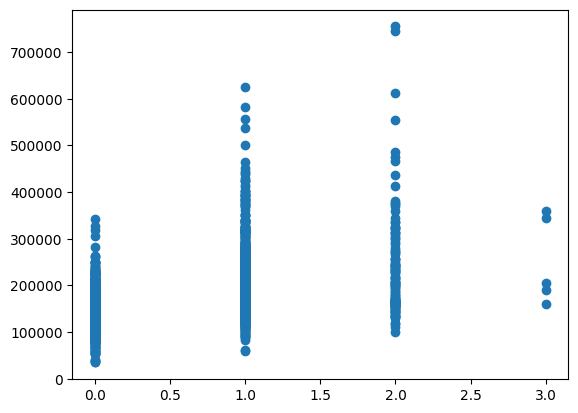

In [62]:
plt.scatter(x = 'Fireplaces',y = 'SalePrice', data = housing_data)   # visualize Fireplaces vs SalePrice

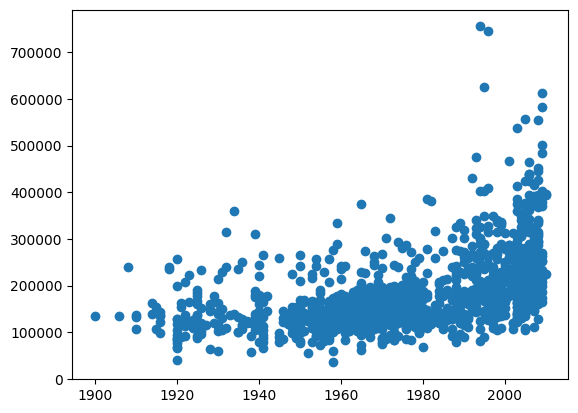

In [63]:
plt.scatter(x = 'GarageYrBlt',y = 'SalePrice', data = housing_data) # visualize GarageYrBlt vs SalePrice

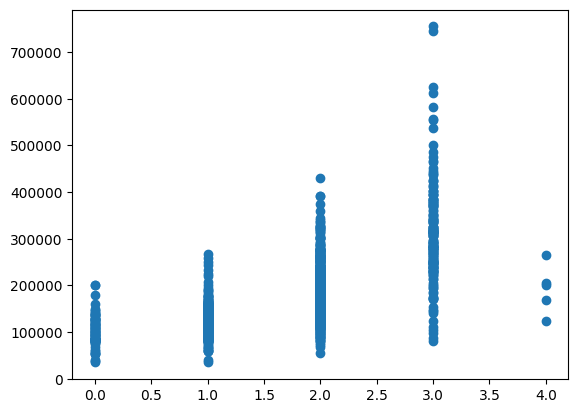

In [64]:
plt.scatter(x = 'GarageCars',y = 'SalePrice', data = housing_data) # visualize GarageCars vs SalePrice

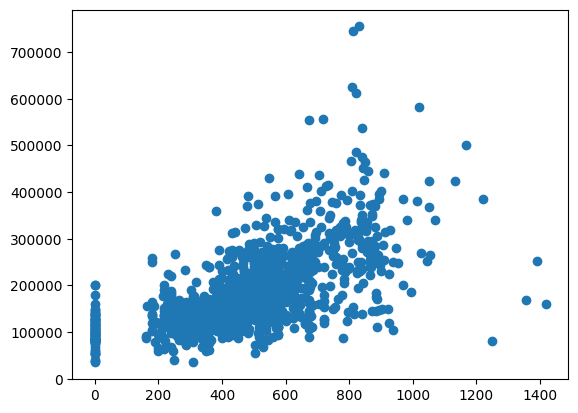

In [65]:
plt.scatter(x = 'GarageArea',y = 'SalePrice', data = housing_data) # visualize GarageArea vs SalePrice

In [66]:
housing_data.query('GarageArea > 1200')   # identify outliers in GarageArea
# 1062,1191

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
581,582,20,RL,98.0,12704,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,8,2009,New,Partial,253293
825,826,20,RL,114.0,14803,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,6,2008,New,Partial,385000
1061,1062,30,C (all),120.0,18000,Grvl,NaN,Reg,Low,AllPub,...,0,NaN,NaN,Shed,560,8,2008,ConLD,Normal,81000
1190,1191,190,RL,NaN,32463,Pave,NaN,Reg,Low,AllPub,...,0,NaN,NaN,NaN,0,3,2007,WD,Normal,168000
1298,1299,60,RL,313.0,63887,Pave,NaN,IR3,Bnk,AllPub,...,480,Gd,NaN,NaN,0,1,2008,New,Partial,160000


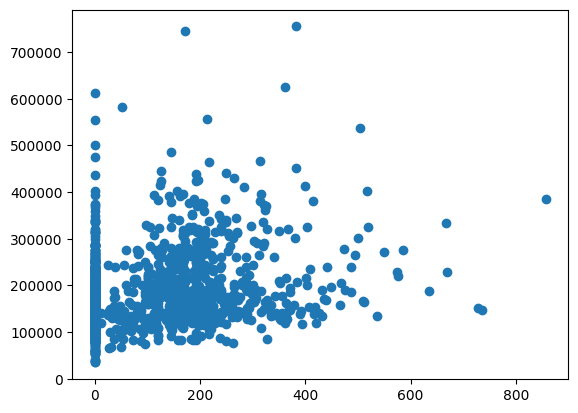

In [67]:
plt.scatter(x = 'WoodDeckSF',y = 'SalePrice', data = housing_data) # visualize WoodDeckSF vs SalePrice

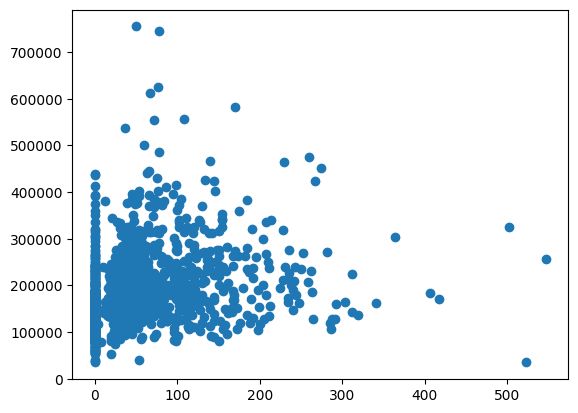

In [68]:
plt.scatter(x = 'OpenPorchSF',y = 'SalePrice', data = housing_data) # visualize OpenPorchSF vs SalePrice    

In [69]:
housing_data.query('OpenPorchSF > 500')   # identify outliers in OpenPorchSF
# 496

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
495,496,30,C (all),60.0,7879,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,GdWo,NaN,0,11,2009,WD,Abnorml,34900
583,584,75,RM,75.0,13500,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,7,2008,WD,Normal,325000
1328,1329,50,RM,60.0,10440,Pave,Grvl,Reg,Lvl,AllPub,...,0,NaN,MnPrv,Shed,1150,6,2008,WD,Normal,256000


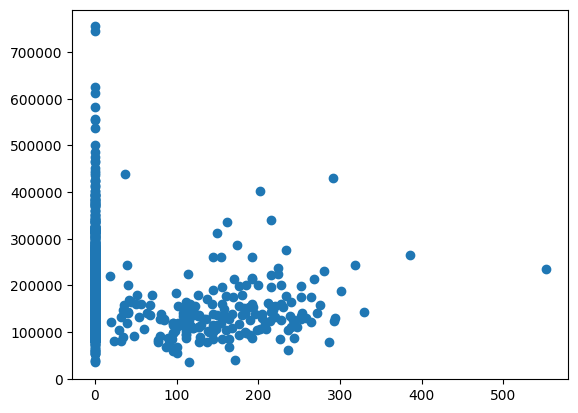

In [70]:
plt.scatter(x = 'EnclosedPorch',y = 'SalePrice', data = housing_data) # visualize EnclosedPorch vs SalePrice

In [71]:
housing_data.query('EnclosedPorch > 500')   # identify outliers in EnclosedPorch
# 198

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
197,198,75,RL,174.0,25419,Pave,NaN,Reg,Lvl,AllPub,...,512,Ex,GdPrv,NaN,0,3,2006,WD,Abnorml,235000


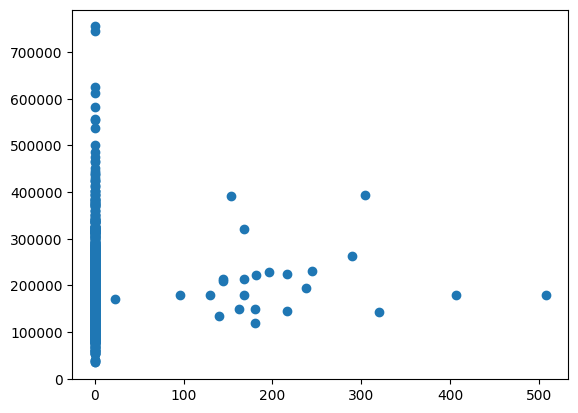

In [72]:
plt.scatter(x = '3SsnPorch',y = 'SalePrice', data = housing_data) # visualize 3SsnPorch vs SalePrice

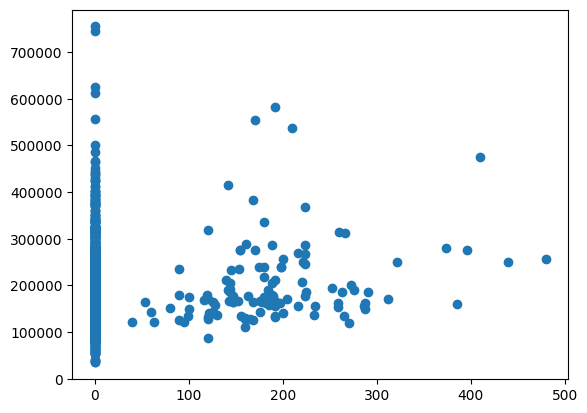

In [73]:
plt.scatter(x = 'ScreenPorch',y = 'SalePrice', data = housing_data) # visualize ScreenPorch vs SalePrice

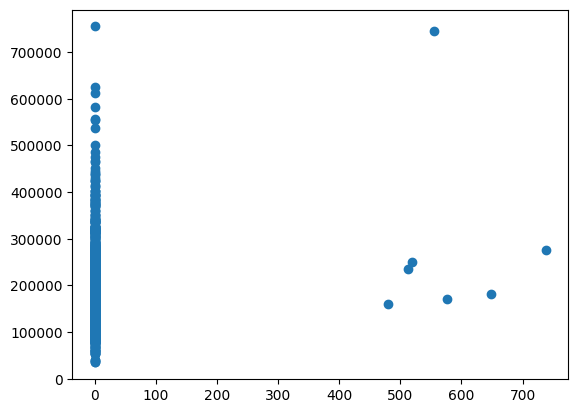

In [74]:
plt.scatter(x = 'PoolArea',y = 'SalePrice', data = housing_data) # visualize PoolArea vs SalePrice

In [75]:
values = [598, 955, 935, 1299, 250, 314, 336, 452, 707, 1397, 524, 379, 1183, 692, 186, 314, 298, 1299, 441, 1299, 524, 1299, 739, 598, 955, 636, 49, 810, 636, 1062, 1191, 496, 198]
    # drop identified outliers

In [76]:
drop_rows = len(values)
drop_rows   # number of rows to be dropped

33

In [77]:
drop_keys = list(dict.fromkeys(values))
drop_keys   # unique row indices to be dropped

[598,
 955,
 935,
 1299,
 250,
 314,
 336,
 452,
 707,
 1397,
 524,
 379,
 1183,
 692,
 186,
 298,
 441,
 739,
 636,
 49,
 810,
 1062,
 1191,
 496,
 198]

In [78]:
housing_data = housing_data[housing_data.Id.isin(values) == False]   # drop outliers from the dataset

In [79]:
pd.DataFrame(housing_data.isnull().sum().sort_values(ascending=False)).head(20)  # check missing values after outlier removal

,0
PoolQC,1431
MiscFeature,1384
Alley,1346
Fence,1159
MasVnrType,858
FireplaceQu,683
LotFrontage,254
GarageQual,76
GarageFinish,76
GarageType,76


In [80]:
housing_data['MiscFeature'].unique()    # check unique values in MiscFeature

array([nan, 'Shed', 'Gar2', 'Othr', 'TenC'], dtype=object)

In [81]:
housing_data['Alley'].unique()      # check unique values in Alley

array([nan, 'Grvl', 'Pave'], dtype=object)

In [82]:
housing_data['Alley'].fillna('No' , inplace=True)       # fill missing values in Alley with 'No'  

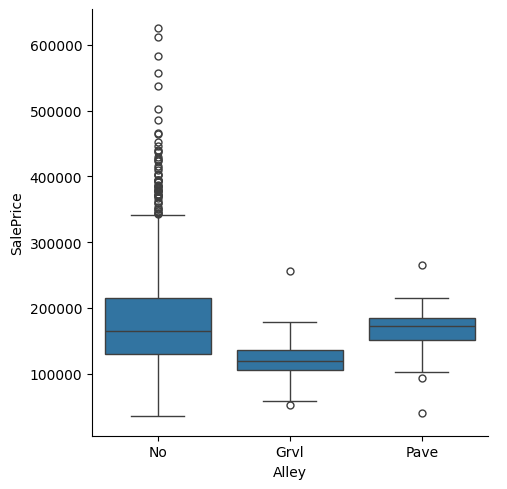

In [83]:
sns.catplot(x='Alley', y='SalePrice', data=housing_data, kind='box')        # visualize Alley vs SalePrice using boxplot

In [84]:
housing_data['Fence'].unique()      # check unique values in Fence

array([nan, 'MnPrv', 'GdWo', 'GdPrv', 'MnWw'], dtype=object)

In [85]:
housing_data['Fence'].fillna('No' , inplace=True)    # fill missing values in Fence with 'No'

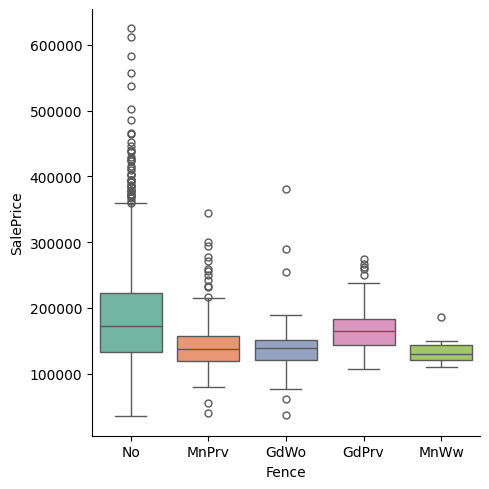

In [86]:
sns.catplot(x='Fence', y='SalePrice',data=housing_data, kind= 'box',palette='Set2')      # visualize Fence vs SalePrice using boxplot

In [87]:
housing_data['MasVnrType'].unique()     # check unique values in MasVnrType

array(['BrkFace', nan, 'Stone', 'BrkCmn'], dtype=object)

In [88]:
housing_data['MasVnrType'].fillna('No', inplace=True)       # fill missing values in MasVnrType with 'No'

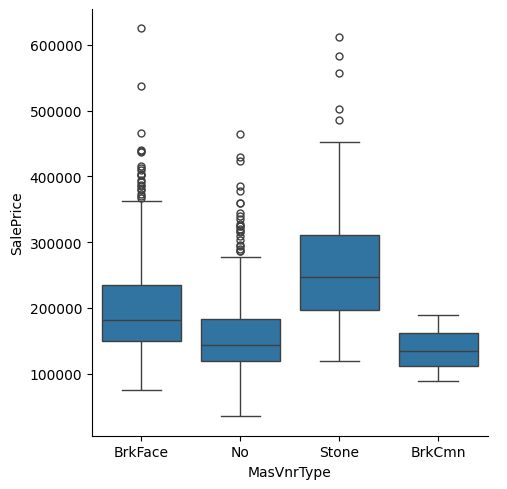

In [89]:
sns.catplot(x='MasVnrType', y='SalePrice', data=housing_data, kind='box')       # visualize MasVnrType vs SalePrice using boxplot

In [90]:
housing_data['FireplaceQu'].unique()     # check unique values in FireplaceQu

array([nan, 'TA', 'Gd', 'Fa', 'Ex', 'Po'], dtype=object)

In [91]:
housing_data['FireplaceQu'].fillna('No', inplace=True)    # fill missing values in FireplaceQu with 'No'

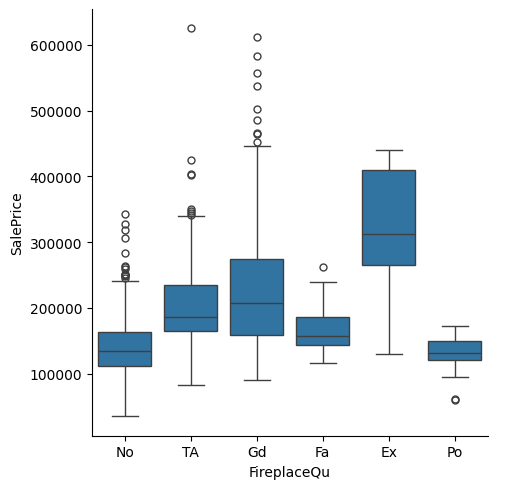

In [92]:
sns.catplot(x='FireplaceQu', y='SalePrice', data=housing_data, kind='box')      # visualize FireplaceQu vs SalePrice using boxplot

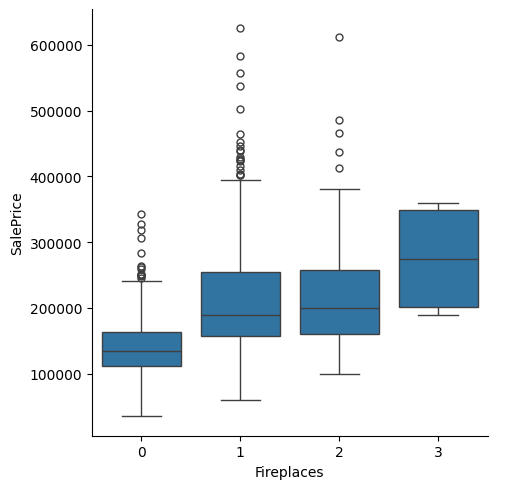

In [93]:
 sns.catplot(x='Fireplaces', y='SalePrice', data=housing_data, kind='box')      # visualize Fireplaces vs SalePrice using boxplot

In [94]:
housing_data['LotFrontage'].fillna(0, inplace=True)   # fill missing values in LotFrontage with 0

In [95]:
housing_data['GarageYrBlt'].corr(housing_data['YearBuilt'])     # check correlation between GarageYrBlt and YearBuilt   

np.float64(0.8280215065429495)

In [96]:
housing_data['GarageCond'].unique()    # check unique values in GarageCond

array(['TA', 'Fa', nan, 'Gd', 'Po', 'Ex'], dtype=object)

In [97]:
housing_data['GarageCond'].fillna('No', inplace=True)   # fill missing values in GarageCond with 'No'

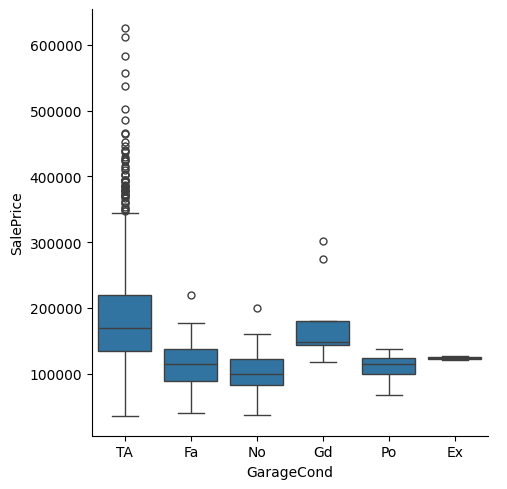

In [98]:
sns.catplot(x='GarageCond', y='SalePrice', data=housing_data, kind='box')   # visualize GarageCond vs SalePrice using boxplot

In [99]:
housing_data['GarageType'].fillna('No', inplace=True)       # fill missing values in GarageType with 'No'

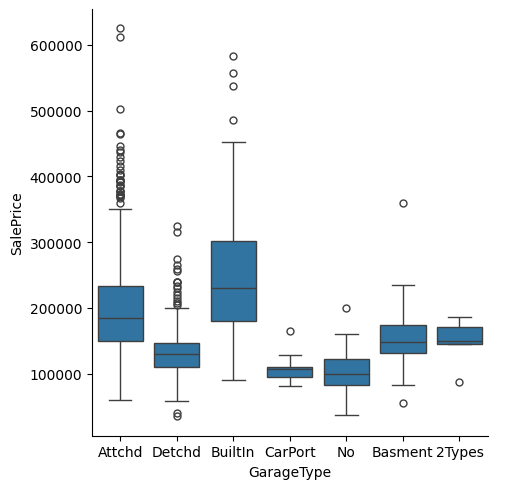

In [100]:
sns.catplot(x='GarageType', y='SalePrice', data=housing_data, kind='box')   # visualize GarageType vs SalePrice using boxplot

In [101]:
housing_data['GarageFinish'].fillna('No', inplace=True)      # fill missing values in GarageFinish with 'No'

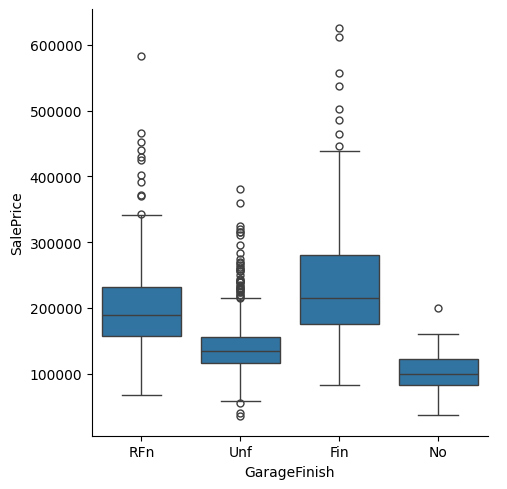

In [102]:
sns.catplot(x='GarageFinish', y='SalePrice', data=housing_data, kind='box')  # visualize GarageFinish vs SalePrice using boxplot

In [103]:
housing_data['GarageQual'].fillna('No', inplace=True)    # fill missing values in GarageQual with 'No'

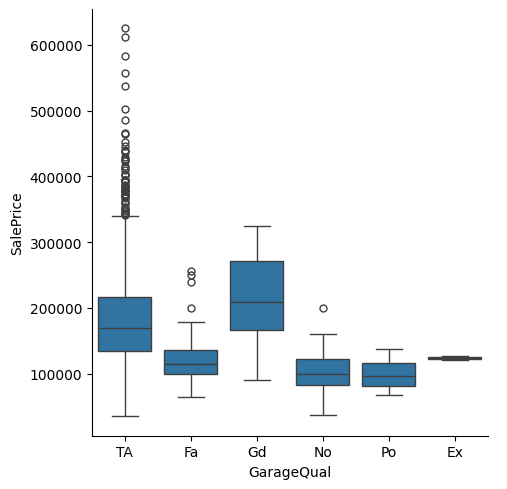

In [104]:
sns.catplot(x='GarageQual', y='SalePrice', data=housing_data, kind='box')   # visualize GarageQual vs SalePrice using boxplot

In [105]:
housing_data['BsmtFinType2'].unique()   # check unique values in BsmtFinType2

array(['Unf', 'BLQ', nan, 'ALQ', 'Rec', 'LwQ', 'GLQ'], dtype=object)

In [106]:
housing_data['BsmtFinType2'].fillna('Unf', inplace=True)    # fill missing values in BsmtFinType2 with 'Unf'

In [107]:
housing_data['BsmtFinType2'].unique()   # check unique values in BsmtFinType2

array(['Unf', 'BLQ', 'ALQ', 'Rec', 'LwQ', 'GLQ'], dtype=object)

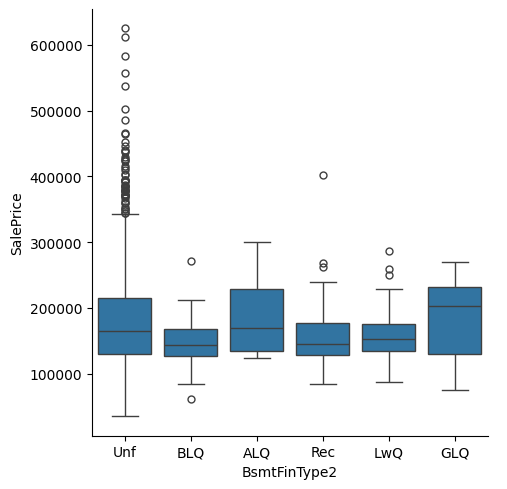

In [108]:
sns.catplot(x='BsmtFinType2', y='SalePrice', data=housing_data, kind='box')  # visualize BsmtFinType2 vs SalePrice using boxplot

In [109]:
housing_data['BsmtExposure'].unique()   # check unique values in BsmtExposure

array(['No', 'Gd', 'Mn', 'Av', nan], dtype=object)

In [110]:
housing_data['BsmtExposure'].fillna('Nb', inplace=True)     # fill missing values in BsmtExposure with 'Nb'

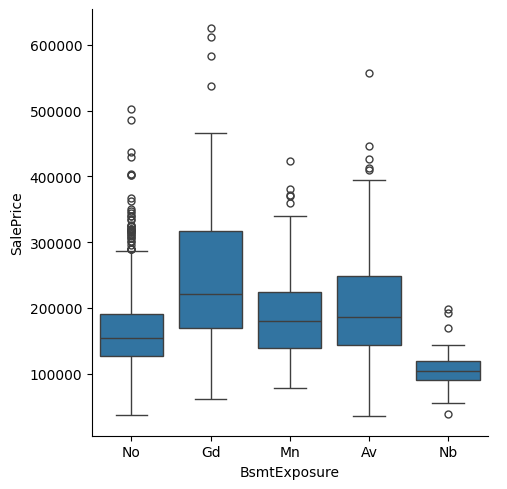

In [111]:
sns.catplot(x='BsmtExposure', y='SalePrice', data=housing_data, kind='box') # visualize BsmtExposure vs SalePrice using boxplot

In [112]:
housing_data['BsmtQual'].unique()   # check unique values in BsmtQual

array(['Gd', 'TA', 'Ex', nan, 'Fa'], dtype=object)

In [113]:
housing_data['BsmtQual'].fillna('No', inplace=True)     # fill missing values in BsmtQual with 'No'

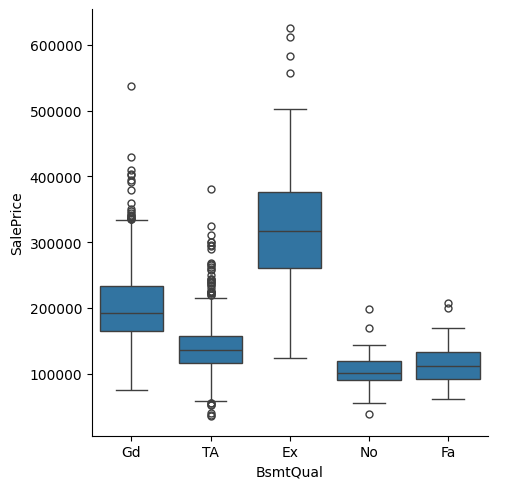

In [114]:
sns.catplot(x='BsmtQual', y='SalePrice', data=housing_data, kind='box')  # visualize BsmtQual vs SalePrice using boxplot

In [115]:
housing_data['BsmtCond'].unique()   # check unique values in BsmtCond

array(['TA', 'Gd', nan, 'Fa', 'Po'], dtype=object)

In [116]:
housing_data['BsmtCond'].fillna('No', inplace=True)    # fill missing values in BsmtCond with 'No'

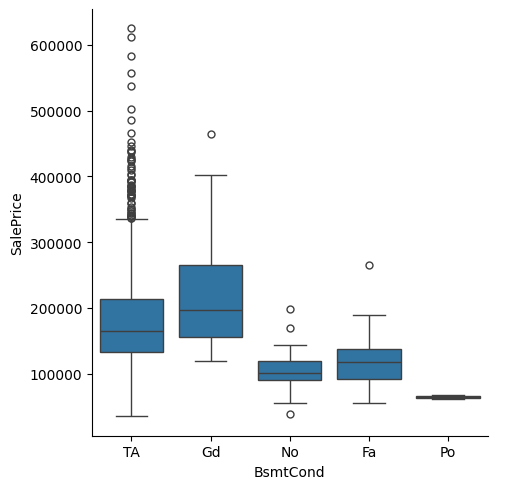

In [117]:
sns.catplot(x='BsmtCond', y='SalePrice', data=housing_data, kind='box')  # visualize BsmtCond vs SalePrice using boxplot

In [118]:
housing_data['BsmtFinType1'].unique()   # check unique values in BsmtFinType1

array(['GLQ', 'ALQ', 'Unf', 'Rec', 'BLQ', nan, 'LwQ'], dtype=object)

In [119]:
housing_data['BsmtFinType1'].fillna('Unf', inplace=True)    # fill missing values in BsmtFinType1 with 'Unf'

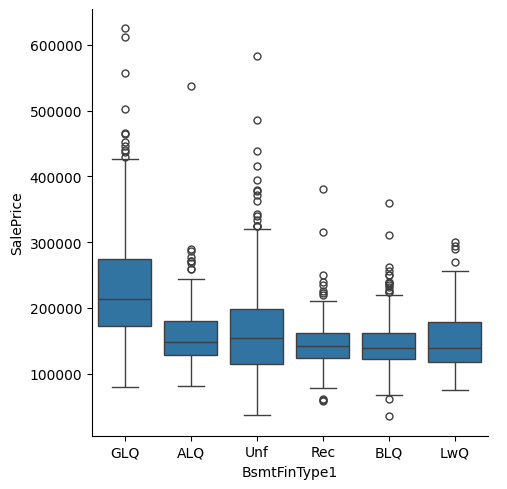

In [120]:
sns.catplot(x='BsmtFinType1', y='SalePrice', data=housing_data, kind='box')     # visualize BsmtFinType1 vs SalePrice using boxplot

In [121]:
housing_data['MasVnrArea'].fillna(0, inplace=True)    # fill missing values in MasVnrArea with 0

In [122]:
housing_data['Electrical'].fillna('SBrkr', inplace=True)    # fill missing values in Electrical with 'SBrkr'

In [123]:
housing_data = housing_data.drop(
    columns=['PoolQC', 'MiscFeature', 'Alley', 'Fence',
             'GarageYrBlt', 'GarageCond', 'BsmtCond', 'BsmtQual']
)                                                                       # drop columns with excessive missing values or irrelevant features

# Feature Engineering


New features were created to enhance model performance by incorporating domain knowledge.

New features are created using domain knowledge to improve
model performance and capture important property characteristics.


### Engineered Features:
- `housing_age` – Age of the house
- `houseremodel_age` – Years since last renovation
- `totalsf` – Total square footage
- `totalarea` – Combined area-related features
- `totalbaths` – Total number of bathrooms
- `totalporchsf` – Total porch area

---

In [124]:
housing_data['housing_age'] = housing_data['YrSold'] - housing_data['YearBuilt']    # create new feature housing_age

In [125]:
housing_data['houseremodel_age'] = housing_data['YrSold'] - housing_data['YearRemodAdd']    # create new feature houseremodel_age

In [126]:
housing_data['totalsf']= housing_data['BsmtFinSF1'] + housing_data['1stFlrSF'] + housing_data['2ndFlrSF']   # create new feature totalsf

In [127]:
housing_data['totalarea'] = housing_data['GrLivArea'] + housing_data['TotalBsmtSF']  # create new feature totalarea

In [128]:
housing_data['totalbaths'] = housing_data['BsmtFullBath'] + housing_data['FullBath'] + 0.5 * (housing_data['BsmtHalfBath'] + housing_data['HalfBath'])  

In [129]:
housing_data['totalporchsf'] = housing_data['OpenPorchSF'] + housing_data['3SsnPorch'] + housing_data['EnclosedPorch'] + housing_data['ScreenPorch'] + housing_data['WoodDeckSF'] # create new feature totalporchsf

In [130]:
print(housing_data.columns.tolist())    # display updated column names after feature engineering

['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1', 'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual', 'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual', 'PavedDrive', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal', 'MoSold', 'YrSold', 'SaleType', 'SaleCondition', 'SalePrice

In [131]:
housing_data = housing_data.drop(columns=['YrSold','YearBuilt','YearRemodAdd','1stFlrSF','2ndFlrSF','BsmtFinSF1','GrLivArea','TotalBsmtSF','OpenPorchSF','3SsnPorch','EnclosedPorch','ScreenPorch','WoodDeckSF','GarageArea'])  # drop original columns used for feature engineering

Text(0.5, 1.0, 'Correlation Matrix')

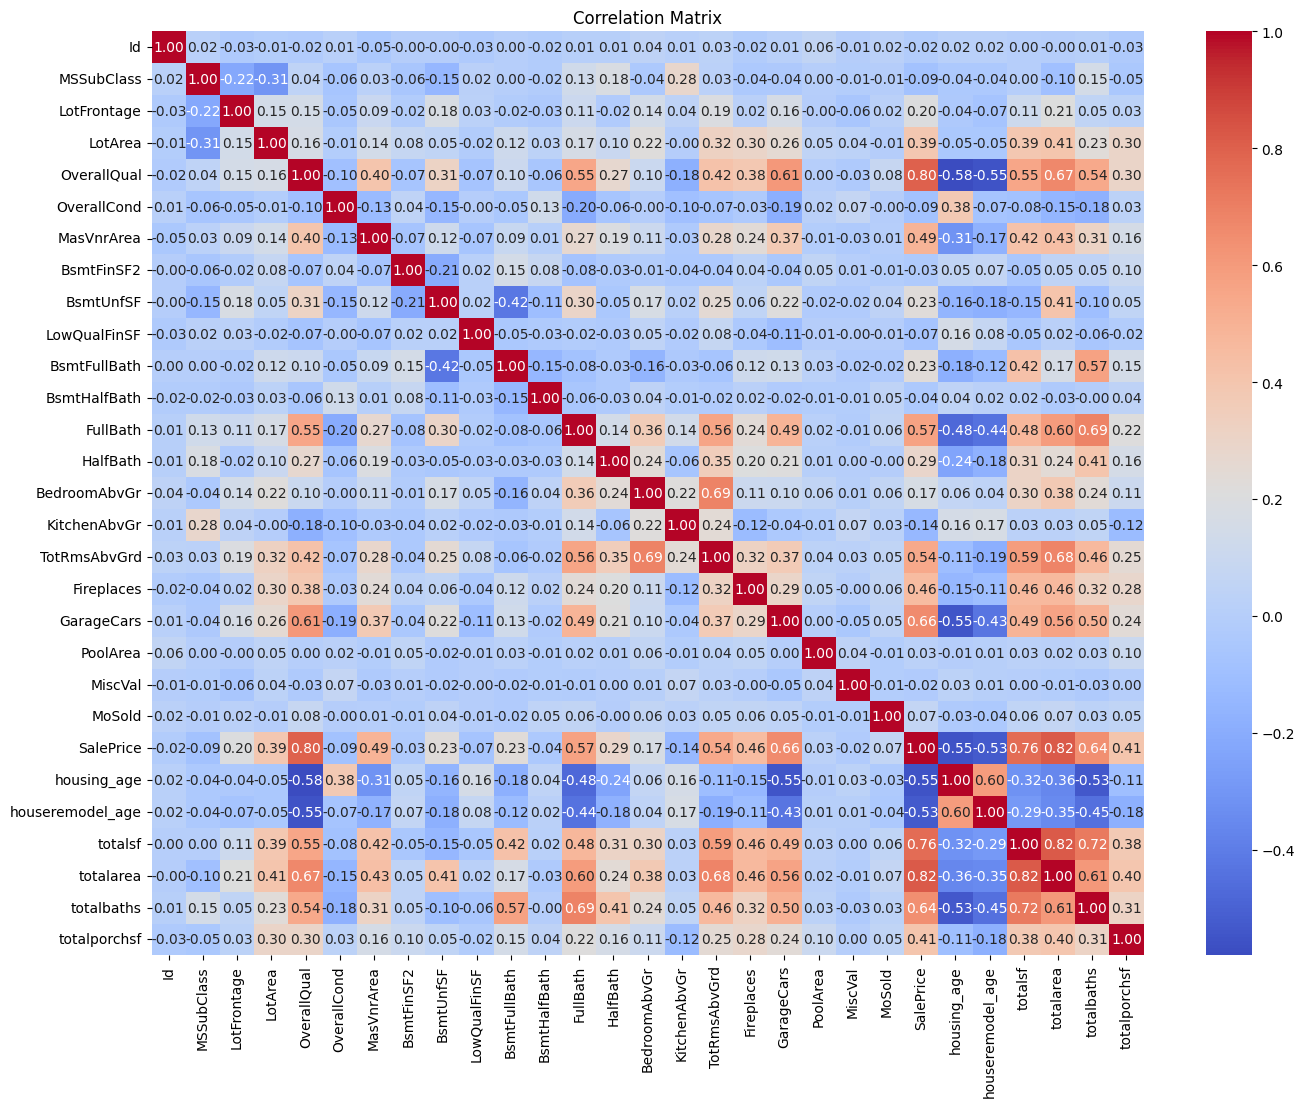

In [132]:
correlation_matrix = housing_data.corr(numeric_only=True)
plt.figure(figsize=(16,12))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Correlation Matrix')                                              # visualize correlation matrix

<Axes: xlabel='SalePrice', ylabel='Count'>

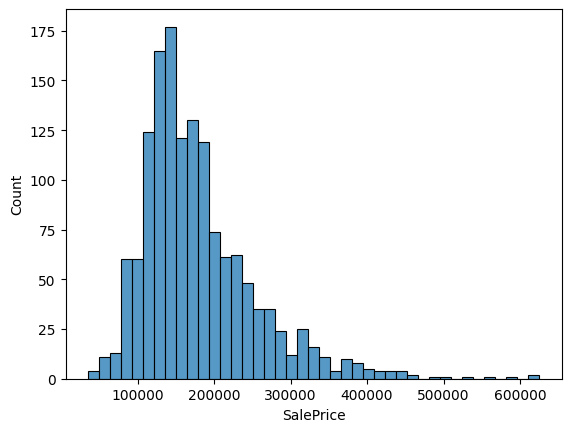

In [133]:
sns.histplot(housing_data,x=housing_data['SalePrice'])  # visualize distribution of SalePrice

In [134]:
housing_data['SalePrice'] = np.log1p(housing_data['SalePrice'])  # log-transform SalePrice to reduce skewness

<Axes: xlabel='SalePrice', ylabel='Count'>

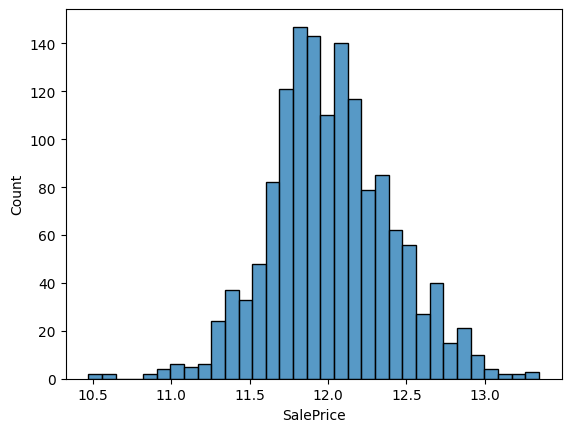

In [135]:
sns.histplot(housing_data,x=housing_data['SalePrice'])  # visualize distribution of SalePrice after log-transformation

In [136]:
housing_data.dtypes[housing_data.dtypes == 'object']    # categorical feature data types after feature engineering

MSZoning         object
Street           object
LotShape         object
LandContour      object
Utilities        object
LotConfig        object
LandSlope        object
Neighborhood     object
Condition1       object
Condition2       object
BldgType         object
HouseStyle       object
RoofStyle        object
RoofMatl         object
Exterior1st      object
Exterior2nd      object
MasVnrType       object
ExterQual        object
ExterCond        object
Foundation       object
BsmtExposure     object
BsmtFinType1     object
BsmtFinType2     object
Heating          object
HeatingQC        object
CentralAir       object
Electrical       object
KitchenQual      object
Functional       object
FireplaceQu      object
GarageType       object
GarageFinish     object
GarageQual       object
PavedDrive       object
SaleType         object
SaleCondition    object
dtype: object

In [137]:
ode_cols = [
    'ExterQual',
    'ExterCond',
    'BsmtExposure',
    'BsmtFinType1',
    'BsmtFinType2',
    'HeatingQC',
    'KitchenQual',
    'Functional',
    'FireplaceQu',
    'GarageFinish',
    'GarageQual',
    'PavedDrive'
]                                    # ordinal categorical columns


In [138]:
ohe_cols = [
    'MSZoning',
    'Street',
    'LotShape',
    'LandContour',
    'Utilities',
    'LotConfig',
    'LandSlope',
    'Neighborhood',
    'Condition1',
    'Condition2',
    'BldgType',
    'HouseStyle',
    'RoofStyle',
    'RoofMatl',
    'Exterior1st',
    'Exterior2nd',
    'MasVnrType',
    'Foundation',
    'Heating',
    'CentralAir',
    'Electrical',
    'GarageType',
    'SaleType',
    'SaleCondition'
]                               # nominal categorical columns


In [139]:
assert set(ode_cols).isdisjoint(ohe_cols)
print("ODE & OHE split is correct ✅")                # verify no overlap between ODE and OHE columns


ODE & OHE split is correct ✅


In [140]:
num_cols = housing_data.select_dtypes(include=['int64','float64']).columns  # numerical columns after feature engineering
num_cols = num_cols.drop('SalePrice')                                       # remove SalePrice from numerical columns

## 6. Data Preprocessing
A preprocessing pipeline was built using **Scikit-learn Pipelines** and **ColumnTransformer**.

### Numerical Features:
- Missing value imputation
- Feature scaling

### Categorical Features:
- Missing value handling
- Encoding

Using pipelines ensured:
- No data leakage
- Reproducibility
- Consistent transformations across training and test data

In [141]:
num_pipline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])                                                      # numerical pipeline: imputation + scaling

In [142]:
odo_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),   
    ('ode', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))
])                                                                                     # ordinal encoding pipeline


In [143]:
ohe_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),   
    ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])                                                                                    # one-hot encoding pipeline

In [144]:
col_trans = ColumnTransformer(transformers=[
    ('num_p', num_pipline, num_cols),
    ('ode_p', ohe_pipeline, ode_cols),
    ('ohe_p', odo_pipeline, ohe_cols),
],                      
 remainder='passthrough',
n_jobs=-1)                                       # column transformer to apply pipelines to respective columns

In [145]:
preprocess_pipelines = Pipeline(
 steps=[('preprocessing', col_trans)]
)                                        # full preprocessing pipelines

In [146]:
X = housing_data.drop('SalePrice', axis=1)      # features
y = housing_data['SalePrice']                   # target variable

In [147]:
X_preprocessed =preprocess_pipelines.fit_transform(X)       # preprocess features

In [148]:
X_train, X_test, y_train, y_test = train_test_split(X_preprocessed, y, test_size=0.2, random_state=42)      # split data into training and testing sets

##  Model Building
Multiple regression models were trained and evaluated:

- Gradient Boosting Regressor
- XGBoost Regressor
- LightGBM Regressor
- Random Forest Regressor
- Ridge Regression



Multiple regression models are trained including ensemble methods.
Hyperparameter tuning is performed using cross-validation.


### Stacking Regressor
A **Stacking Regressor** was used as the final model.  
It combines multiple base models and uses a meta-model to improve overall prediction accuracy.

The target variable was log-transformed during training to handle skewness.

---

In [149]:
lr = LinearRegression()               # initialize linear regression model

In [150]:
lr.fit(X_train, y_train)              # train the model

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [151]:
y_pred_lr= lr.predict(X_test)       # make predictions on the test set

In [152]:
mean_squared_error(y_test, y_pred_lr)       # evaluate model performance using Mean Squared Error

0.018353325702695777

### Random Forest Regressor
Random Forest trains multiple decision trees using bagging.  
It reduces variance and improves model stability.  
It performs well on non-linear data.

In [153]:
RFR = RandomForestRegressor(random_state=13)        # initialize Random Forest Regressor model

In [154]:
param_grid_RFR = {
    'max_depth': [5, 10, 15],
    'n_estimators': [100, 250, 500 ],
    'min_samples_split': [3, 5, 10]
}                                          # hyperparameter grid for Random Forest Regressor

In [155]:
rfr_cv = GridSearchCV(RFR, param_grid_RFR, cv=5, scoring='neg_mean_squared_error', n_jobs=1)        # set up GridSearchCV for hyperparameter tuning

In [156]:
rfr_cv.fit(X_train, y_train)      # perform hyperparameter tuning with cross-validation

,estimator,RandomForestR...ndom_state=13)
,param_grid,"{'max_depth': [5, 10, ...], 'min_samples_split': [3, 5, ...], 'n_estimators': [100, 250, ...]}"
,scoring,'neg_mean_squared_error'
,n_jobs,1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,500


In [157]:
np.sqrt(-1 * rfr_cv.best_score_)    # display best RMSE from cross-validation

np.float64(0.1342628658608787)

In [158]:
rfr_cv.best_params_             # display best hyperparameters found

{'max_depth': 15, 'min_samples_split': 3, 'n_estimators': 500}

### XGBoost Regressor
XGBoost is an optimized boosting algorithm with regularization.  
It improves prediction accuracy and prevents overfitting.  
It performs well on large and complex datasets.

In [159]:
XGB = XGBRegressor(random_state=13)         # initialize XGBoost Regressor model

In [160]:
param_grid = {
    'learning_rate': [0.05, 0.1, 0.2],
    'n_estimators': [300],
    'max_depth': [3],
    'min_child_weight': [1,2,3],
    'gamma': [0, 0.1, 0.2],
    'subsample': [0.8, 0.9, 1.0],
    'colsample_bytree': [0.8, 0.9, 1.0]
}                                               # hyperparameter grid for XGBoost Regressor

In [161]:
xgb_cv = GridSearchCV(XGB, param_grid, cv=5, scoring='neg_mean_squared_error', n_jobs=1)      # set up GridSearchCV for hyperparameter tuning of XGBoost Regressor

In [162]:
xgb_cv.fit(X_train, y_train)                  # perform hyperparameter tuning with cross-validation

,estimator,"XGBRegressor(...ree=None, ...)"
,param_grid,"{'colsample_bytree': [0.8, 0.9, ...], 'gamma': [0, 0.1, ...], 'learning_rate': [0.05, 0.1, ...], 'max_depth': [3], ...}"
,scoring,'neg_mean_squared_error'
,n_jobs,1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,objective,'reg:squarederror'


In [163]:
np.sqrt(-1 * xgb_cv.best_score_)           # display best RMSE from cross-validation for XGBoost Regressor

np.float64(0.11485246573673122)

### Ridge Regression
Ridge Regression is a linear model with L2 regularization.  
It reduces multicollinearity and overfitting.  
It serves as a strong baseline model.

In [164]:
ridge = Ridge()                  # initialize Ridge Regression model

In [165]:
param_grid_ridge = {
    'alpha': [0.05, 0.1, 1, 3, 5, 10],
    'solver': ['auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag']
}                                                                           # hyperparameter grid for Ridge Regression

In [166]:
ridge_cv = GridSearchCV(ridge, param_grid_ridge, cv=5, scoring='neg_mean_squared_error', n_jobs=1)   # set up GridSearchCV for hyperparameter tuning of Ridge Regression

In [167]:
ridge_cv.fit(X_train, y_train)             # perform hyperparameter tuning with cross-validation

,estimator,Ridge()
,param_grid,"{'alpha': [0.05, 0.1, ...], 'solver': ['auto', 'svd', ...]}"
,scoring,'neg_mean_squared_error'
,n_jobs,1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,alpha,10


In [168]:
np.sqrt(-1 * ridge_cv.best_score_)      # display best RMSE from cross-validation for Ridge Regression

np.float64(0.11511004063877961)

### Gradient Boosting Regressor
This model builds trees sequentially to correct previous errors.  
It captures complex non-linear patterns in the data.  
It provides strong performance on structured datasets.

In [169]:
GBR = GradientBoostingRegressor()     # initialize Gradient Boosting Regressor model

In [170]:
param_grid_GBR = {
    'max_depth': [12, 15, 20],
    'n_estimators': [200, 300, 1000],
    'min_samples_leaf': [10, 25, 50],
    'learning_rate': [0.001, 0.01, 0.2],
    'max_features': [0.01, 0.1, 0.7]
}                                               # hyperparameter grid for Gradient Boosting Regressor

In [171]:
GBR_cv = GridSearchCV(GBR, param_grid_GBR, cv=5, scoring='neg_mean_squared_error', n_jobs=1)    # set up GridSearchCV for hyperparameter tuning of Gradient Boosting Regressor

In [172]:
GBR_cv.fit(X_train, y_train)        # perform hyperparameter tuning with cross-validation

,estimator,GradientBoostingRegressor()
,param_grid,"{'learning_rate': [0.001, 0.01, ...], 'max_depth': [12, 15, ...], 'max_features': [0.01, 0.1, ...], 'min_samples_leaf': [10, 25, ...], ...}"
,scoring,'neg_mean_squared_error'
,n_jobs,1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,loss,'squared_error'


In [173]:
np.sqrt(-1 * GBR_cv.best_score_)        # display best RMSE from cross-validation for Gradient Boosting Regressor

np.float64(0.11397876910485395)

## LightGBM Regressor
LightGBM uses leaf-wise tree growth for faster training.  
It handles large datasets efficiently with high accuracy.  
It reduces memory usage and training time.

In [174]:
lgbm_regressor = lgbm.LGBMRegressor()    # initialize LightGBM Regressor model

In [175]:
param_grid_ridge = {
    'boosting_type': ['gbdt', 'dart'],
    'num_leaves': [20, 30, 40],
    'learning_rate': [0.01, 0.05, 0.1],
    'n_estimators': [100, 200, 300]
}                                           # hyperparameter grid for LightGBM Regressor

In [176]:
lgbm_cv = GridSearchCV(lgbm_regressor, param_grid_ridge, cv=5, scoring='neg_mean_squared_error', n_jobs=1)      # set up GridSearchCV for hyperparameter tuning of LightGBM Regressor

In [177]:
lgbm_cv.fit(X_train, y_train)          # perform hyperparameter tuning with cross-validation

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001508 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2209
[LightGBM] [Info] Number of data points in the train set: 918, number of used features: 89
[LightGBM] [Info] Start training from score 12.021014
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001408 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2187
[LightGBM] [Info] Number of data points in the train set: 918, number of used features: 89
[LightGBM] [Info] Start training from score 12.008480
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001151 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2193
[LightGBM] [Info] Number of data points in the train set: 918, number of used features: 87
[LightGBM] [Info] Start trainin

,estimator,LGBMRegressor()
,param_grid,"{'boosting_type': ['gbdt', 'dart'], 'learning_rate': [0.01, 0.05, ...], 'n_estimators': [100, 200, ...], 'num_leaves': [20, 30, ...]}"
,scoring,'neg_mean_squared_error'
,n_jobs,1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,boosting_type,'gbdt'


In [178]:
np.sqrt(-1 * lgbm_cv.best_score_)         # display best RMSE from cross-validation for LightGBM Regressor

np.float64(0.12219302823264204)

### Voting Regressor

Voting Regressor is an ensemble learning technique that combines predictions from multiple regression models.  
Each base model makes its own prediction, and the final output is calculated as the **average (or weighted average)** of all model predictions.  
This approach improves prediction stability and accuracy by reducing the impact of individual model errors.


In [179]:
vr = VotingRegressor(
    estimators=[
        ('gbr', GBR_cv.best_estimator_),
        ('xgb', xgb_cv.best_estimator_),
        ('ridge', ridge_cv.best_estimator_)
        ],
        weights = [2,3,1]
        )                              # initialize Voting Regressor with best estimators from previous models

In [180]:
vr.fit(X_train,y_train)      # train Voting Regressor

,estimators,"[('gbr', ...), ('xgb', ...), ...]"
,weights,"[2, 3, ...]"
,n_jobs,None
,verbose,False
,loss,'squared_error'
,learning_rate,0.01
,n_estimators,1000
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,10


In [181]:
y_pred_vr = vr.predict(X_test)   # make predictions on the test set using Voting Regressor

In [182]:
rmse_vr = np.sqrt(mean_squared_error(y_test, y_pred_vr))
rmse_vr                                                       # evaluate Voting Regressor performance using RMSE


np.float64(0.12322138573172249)

In [183]:
estimators=[
        ('gbr', GBR_cv.best_estimator_),
        ('xgb', xgb_cv.best_estimator_),
        ('lgbm', lgbm_cv.best_estimator_),
        ('rfr', rfr_cv.best_estimator_),
        ('ridge', ridge_cv.best_estimator_),
        ]                                                     # list of estimators for Voting Regressor

## Stacking Regressor

A stacking regressor is used as the final model to combine
predictions from multiple base learners and improve accuracy.


In [184]:
Stackreg = StackingRegressor(
    estimators = estimators,
    final_estimator = vr
)                                               # initialize Stacking Regressor with Voting Regressor as final estimator

In [185]:
Stackreg.fit(X_train, y_train)    # train Stacking Regressor

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000934 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2319
[LightGBM] [Info] Number of data points in the train set: 1148, number of used features: 91
[LightGBM] [Info] Start training from score 12.015147
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000641 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2209
[LightGBM] [Info] Number of data points in the train set: 918, number of used features: 89
[LightGBM] [Info] Start training from score 12.021014
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000848 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2187
[LightGBM] [Info] Number of data points in the train set: 918, number of used features: 89
[LightGBM] [Info] Start traini

,estimators,"[('gbr', ...), ('xgb', ...), ...]"
,final_estimator,"VotingRegress...hts=[2, 3, 1])"
,cv,None
,n_jobs,None
,passthrough,False
,verbose,0
,loss,'squared_error'
,learning_rate,0.01
,n_estimators,1000
,subsample,1.0
,criterion,'friedman_mse'


In [186]:
y_pred_stack = Stackreg.predict(X_test)    # make predictions on the test set using Stacking Regressor

## Model Evaluation

Models are evaluated using Root Mean Squared Error (RMSE).
The stacking regressor achieved the best performance.


In [187]:
rmse_stack = np.sqrt(mean_squared_error(y_test, y_pred_stack))      # evaluate Stacking Regressor performance using RMSE
rmse_stack


np.float64(0.12723746691120083)

In [188]:
X_preprocessed.shape      # display shape of preprocessed feature set


(1435, 113)

##  Model Evaluation
Model performance was evaluated using **Root Mean Squared Error (RMSE)**.

### Model Comparison

| Model | Performance |
|------|------------|
| Gradient Boosting | Moderate |
| XGBoost | Good |
| LightGBM | Better |
| Random Forest | Moderate |
| Ridge Regression | Lower |
| **Stacking Regressor** | **Best (Lowest RMSE)** |

The stacking model achieved the best performance.

--- 

In [189]:
comparison_df = pd.DataFrame({
    'Model': [
        'Gradient Boosting',
        'XGBoost',
        'LightGBM',
        'Random Forest',
        'Ridge Regression',
        'Stacking Regressor'
    ],
    'RMSE': [
        np.sqrt(mean_squared_error(y_test, GBR_cv.best_estimator_.predict(X_test))),
        np.sqrt(mean_squared_error(y_test, xgb_cv.best_estimator_.predict(X_test))),
        np.sqrt(mean_squared_error(y_test, lgbm_cv.best_estimator_.predict(X_test))),
        np.sqrt(mean_squared_error(y_test, rfr_cv.best_estimator_.predict(X_test))),
        np.sqrt(mean_squared_error(y_test, ridge_cv.best_estimator_.predict(X_test))),
        np.sqrt(mean_squared_error(y_test, Stackreg.predict(X_test)))   
    ]
})

comparison_df.sort_values(by='RMSE')          # compare RMSE of different models


,Model,RMSE
0,Gradient Boosting,0.123518
5,Stacking Regressor,0.127237
1,XGBoost,0.130298
4,Ridge Regression,0.133670
2,LightGBM,0.135578
3,Random Forest,0.140555


In [190]:
housing_data_preprocess = preprocess_pipelines.transform(housing_data)    # preprocess the entire dataset

In [191]:
y_stacking = np.exp(Stackreg.predict(housing_data_preprocess))    # make final predictions using Stacking Regressor and reverse log-transformation

## Final Prediction and Output
Predictions were generated on unseen test data.

### Steps Followed:
1. Extracted `Id` from the test dataset
2. Applied the same preprocessing pipeline
3. Generated predictions using the stacking model
4. Applied inverse log transformation using `np.exp()`
5. Saved predictions in CSV format

### Output File: 
Final predictions are generated on unseen test data and
saved in Kaggle submission format.

In [ ]:
test_ids = housing_data['Id'].copy()

y_stacking_out = pd.DataFrame({
    'Id': test_ids,
    'SalePrice': y_stacking
})

y_stacking_out.to_csv('house_price_prediction_stacking.csv', index=False)    # save final predictions to CSV file


## Issues Faced and Error Handling

During the development of this project, several challenges and errors were encountered and resolved:

### Issue: Gradient Boosting Regressor High Runtime

The Gradient Boosting Regressor (GBR) had a significantly higher training time compared to other models.  
This is because GBR builds trees sequentially, where each tree depends on the previous one, making it computationally expensive.  
The issue was handled by tuning hyperparameters (such as reducing the number of estimators and tree depth) and by using faster ensemble models like LightGBM and XGBoost for comparison.

- **Missing and Incorrect Columns**  
  Some features such as `Id` were not available after preprocessing. This was handled by storing required columns separately before transformation.

- **Data Leakage Issues**  
  Initially, predictions were generated on training data instead of test data. This was corrected by applying the preprocessing pipeline only to unseen test data.

- **Model Evaluation Errors**  
  Errors such as `NameError` and unequal list lengths occurred while creating the model comparison table. These were fixed by ensuring all prediction and RMSE variables were properly defined.

- **Handling Skewed Target Variable**  
  The target variable `SalePrice` was highly skewed. Log transformation was applied during training and reversed using `np.exp()` during prediction.

- **Preprocessing Pipeline Issues**  
  Categorical and numerical features required separate handling. Scikit-learn Pipelines and ColumnTransformer were used to ensure consistent preprocessing.

All issues were systematically debugged and resolved, resulting in a stable and reliable end-to-end machine learning pipeline.


## Conclusion

This project demonstrates a complete end-to-end machine learning
pipeline for house price prediction using stacking regression.

---

## Tools and Technologies
- Python
- Pandas, NumPy
- Matplotlib, Seaborn
- Scikit-learn
- XGBoost, LightGBM
- Jupyter Notebook
- VS Code


------------------------------------------------------- **End of Report**   ---------------------------------------------------------------------
                                                                                                                                
                                                                                                                 
                                                                                                                            